# Интерпретация

In [32]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from PyALE import ale

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [33]:
data_path = r'C:\spbu_ml_2026\data\data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()
print(data.dtypes)


Размер датасета: (29905, 83)

Первые строки:
region_name_cat        str
district_cat         int64
corpus_cat           int64
developer_cat        int64
agreement_date         str
                    ...   
price_target       float64
hc_name_cat          int64
interior_cat       float64
class_cat            int64
stage_cat            int64
Length: 83, dtype: object


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

                                  MAPE
LinearRegression_raw             10.07
Lasso_raw                        10.41
GradientBoosting_raw              5.00
LinearRegression_StandardScaler  10.07
Lasso_StandardScaler             10.40
GradientBoosting_StandardScaler   5.00
LinearRegression_MinMaxScaler    10.07
Lasso_MinMaxScaler               10.18
GradientBoosting_MinMaxScaler     4.97


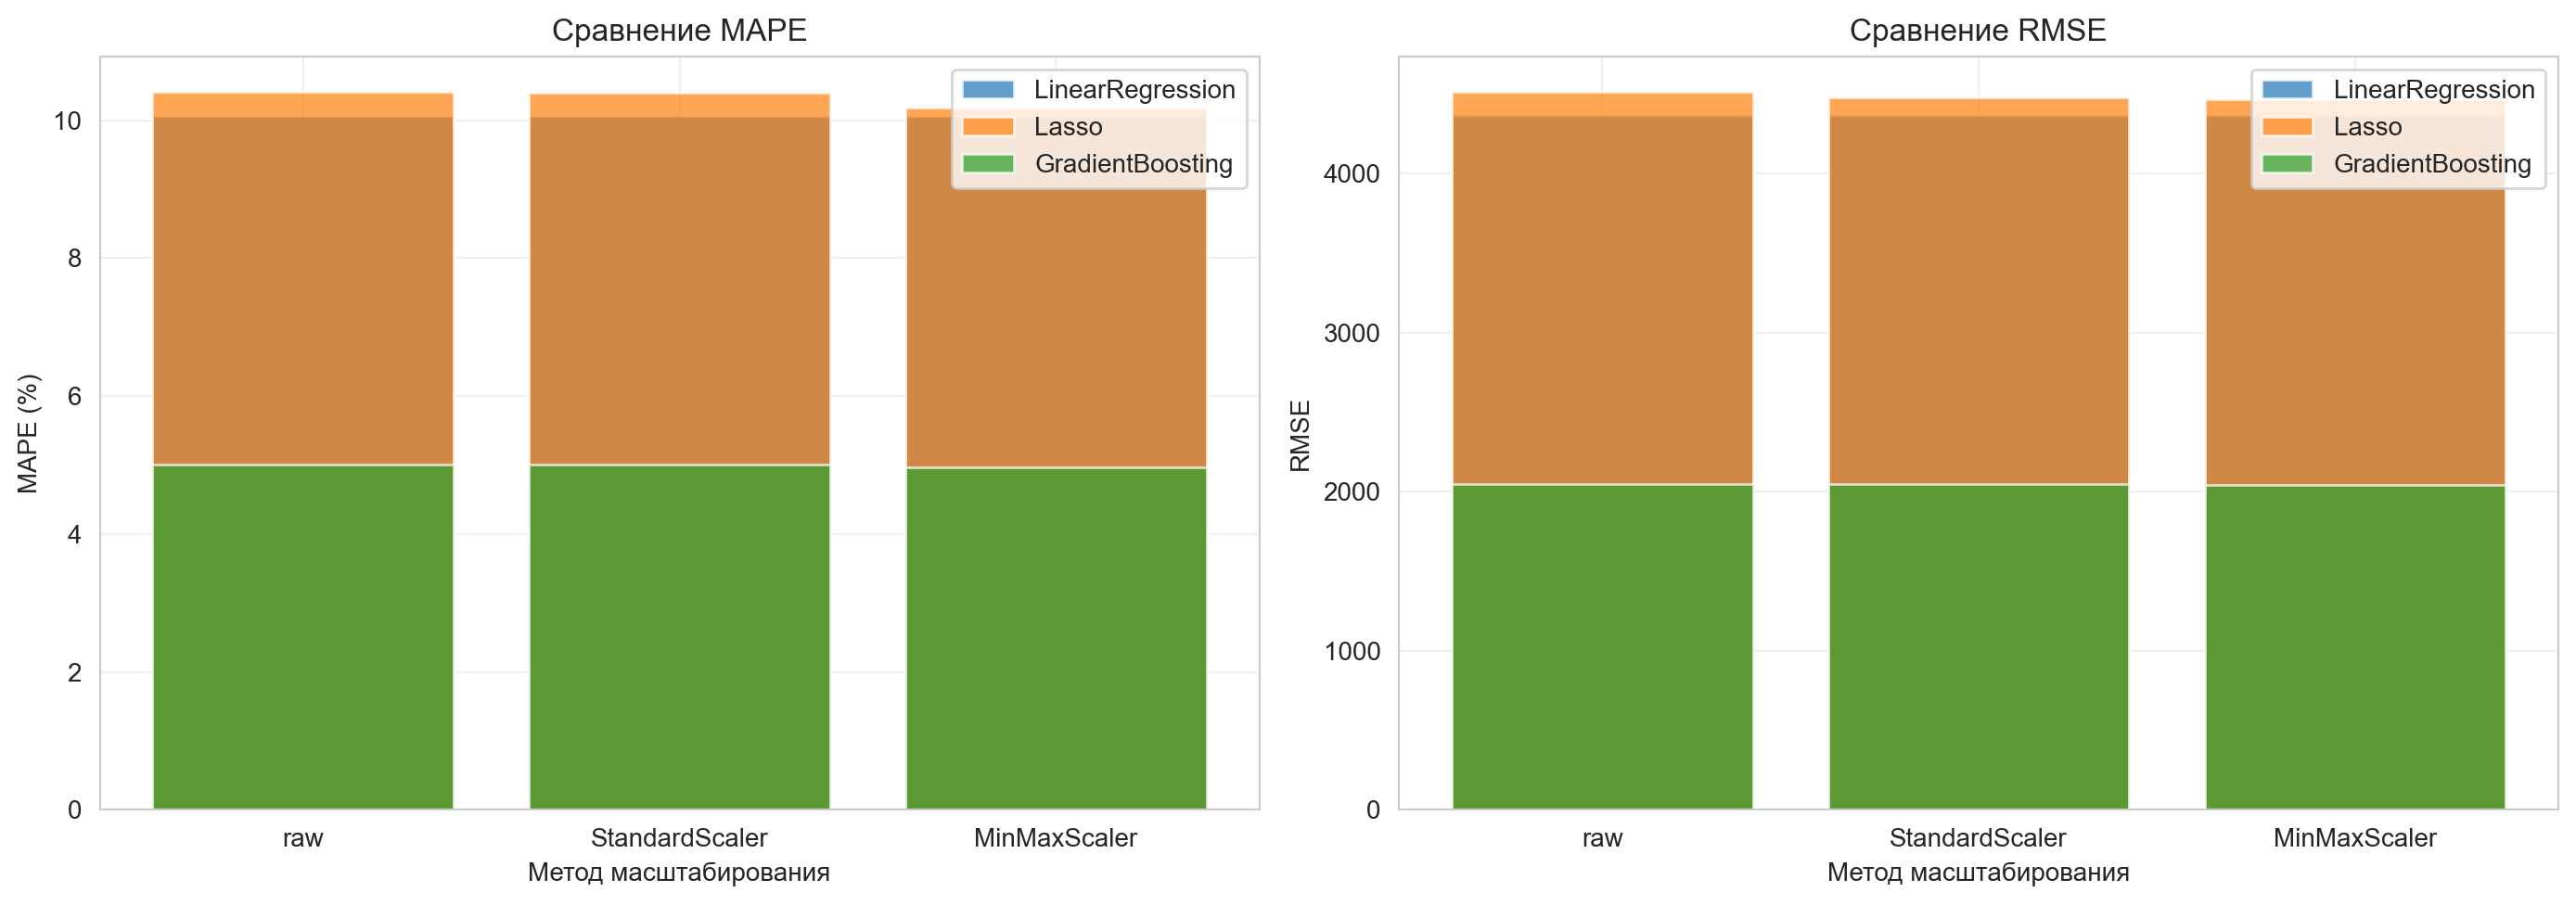


Без масштабирования:
  location_mean_area_density: -2414707.4949
  location_hds_ratio_mean_mean: 50733.7622
  location_motel_cnt: 27751.0376
  location_highway_crossing_w_mean_distance: -24723.7652
  location_public_transport_platform_w_mean_distance: 24529.4333

StandardScaler:
  location_highway_crossing_w_mean_distance: -2307488.9367
  location_public_transport_platform_w_mean_distance: 2289351.1546
  location_std_levels_mean: -129063.2375
  location_shop_other_w_mean_distance: 127242.3734
  location_shop_product_w_mean_distance: 17876.1585

MinMaxScaler:
  location_highway_crossing_w_mean_distance: -24729003.7473
  location_public_transport_platform_w_mean_distance: 24533484.9167
  location_std_levels_mean: -1596843.9866
  location_shop_other_w_mean_distance: 1567230.8316
  location_shop_product_w_mean_distance: 191588.9062


In [36]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('price_target')
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

X = data.drop('price_target', axis=1)
y = data['price_target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])

if cat_cols:
    X_train_cat_raw = imputer_cat.fit_transform(X_train[cat_cols])
    X_test_cat_raw = imputer_cat.transform(X_test[cat_cols])
    X_train_cat = encoder.fit_transform(X_train_cat_raw)
    X_test_cat = encoder.transform(X_test_cat_raw)
    X_train_processed = np.hstack([X_train_num, X_train_cat])
    X_test_processed = np.hstack([X_test_num, X_test_cat])
    cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()
else:
    X_train_processed = X_train_num
    X_test_processed = X_test_num
    cat_feature_names = []

feature_names = num_cols + cat_feature_names

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train_processed)
X_test_std = scaler_std.transform(X_test_processed)

X_train_minmax = scaler_minmax.fit_transform(X_train_processed)
X_test_minmax = scaler_minmax.transform(X_test_processed)

X_train_raw = X_train_processed
X_test_raw = X_test_processed

models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0, max_iter=5000),
    'GradientBoosting': GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=50)
}

scaled_versions = {
    'raw': (X_train_raw, X_test_raw),
    'StandardScaler': (X_train_std, X_test_std),
    'MinMaxScaler': (X_train_minmax, X_test_minmax)
}

results = {}

for scaler_name, (X_tr, X_te) in scaled_versions.items():
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y_test - y_pred) / np.maximum(np.abs(y_test), 1e-10))) * 100

        results[f'{model_name}_{scaler_name}'] = {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

results_df = pd.DataFrame(results).T
print(results_df[['MAPE']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name in models.keys():
    mape_values = [results[f'{model_name}_{s}']['MAPE'] for s in scaled_versions.keys()]
    axes[0].bar(list(scaled_versions.keys()), mape_values, alpha=0.7, label=model_name)

    rmse_values = [results[f'{model_name}_{s}']['RMSE'] for s in scaled_versions.keys()]
    axes[1].bar(list(scaled_versions.keys()), rmse_values, alpha=0.7, label=model_name)

axes[0].set_xlabel('Метод масштабирования')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Сравнение MAPE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Метод масштабирования')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Сравнение RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for scaler_name, (X_tr, X_te) in scaled_versions.items():
    lr = LinearRegression()
    lr.fit(X_tr, y_train)
    coef = lr.coef_

    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = np.abs(coef_df['coef'])
    top5 = coef_df.nlargest(5, 'abs_coef')

    print(f"\n{scaler_name if scaler_name != 'raw' else 'Без масштабирования'}:")
    for _, row in top5.iterrows():
        print(f"  {row['feature']}: {row['coef']:.4f}")

Получилось, что Линейная регрессия нечувствительна к нормализации данных, в то время, как Лассо и Бустинг имеют различия в метриках по сравнению с ненормализованными данными

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

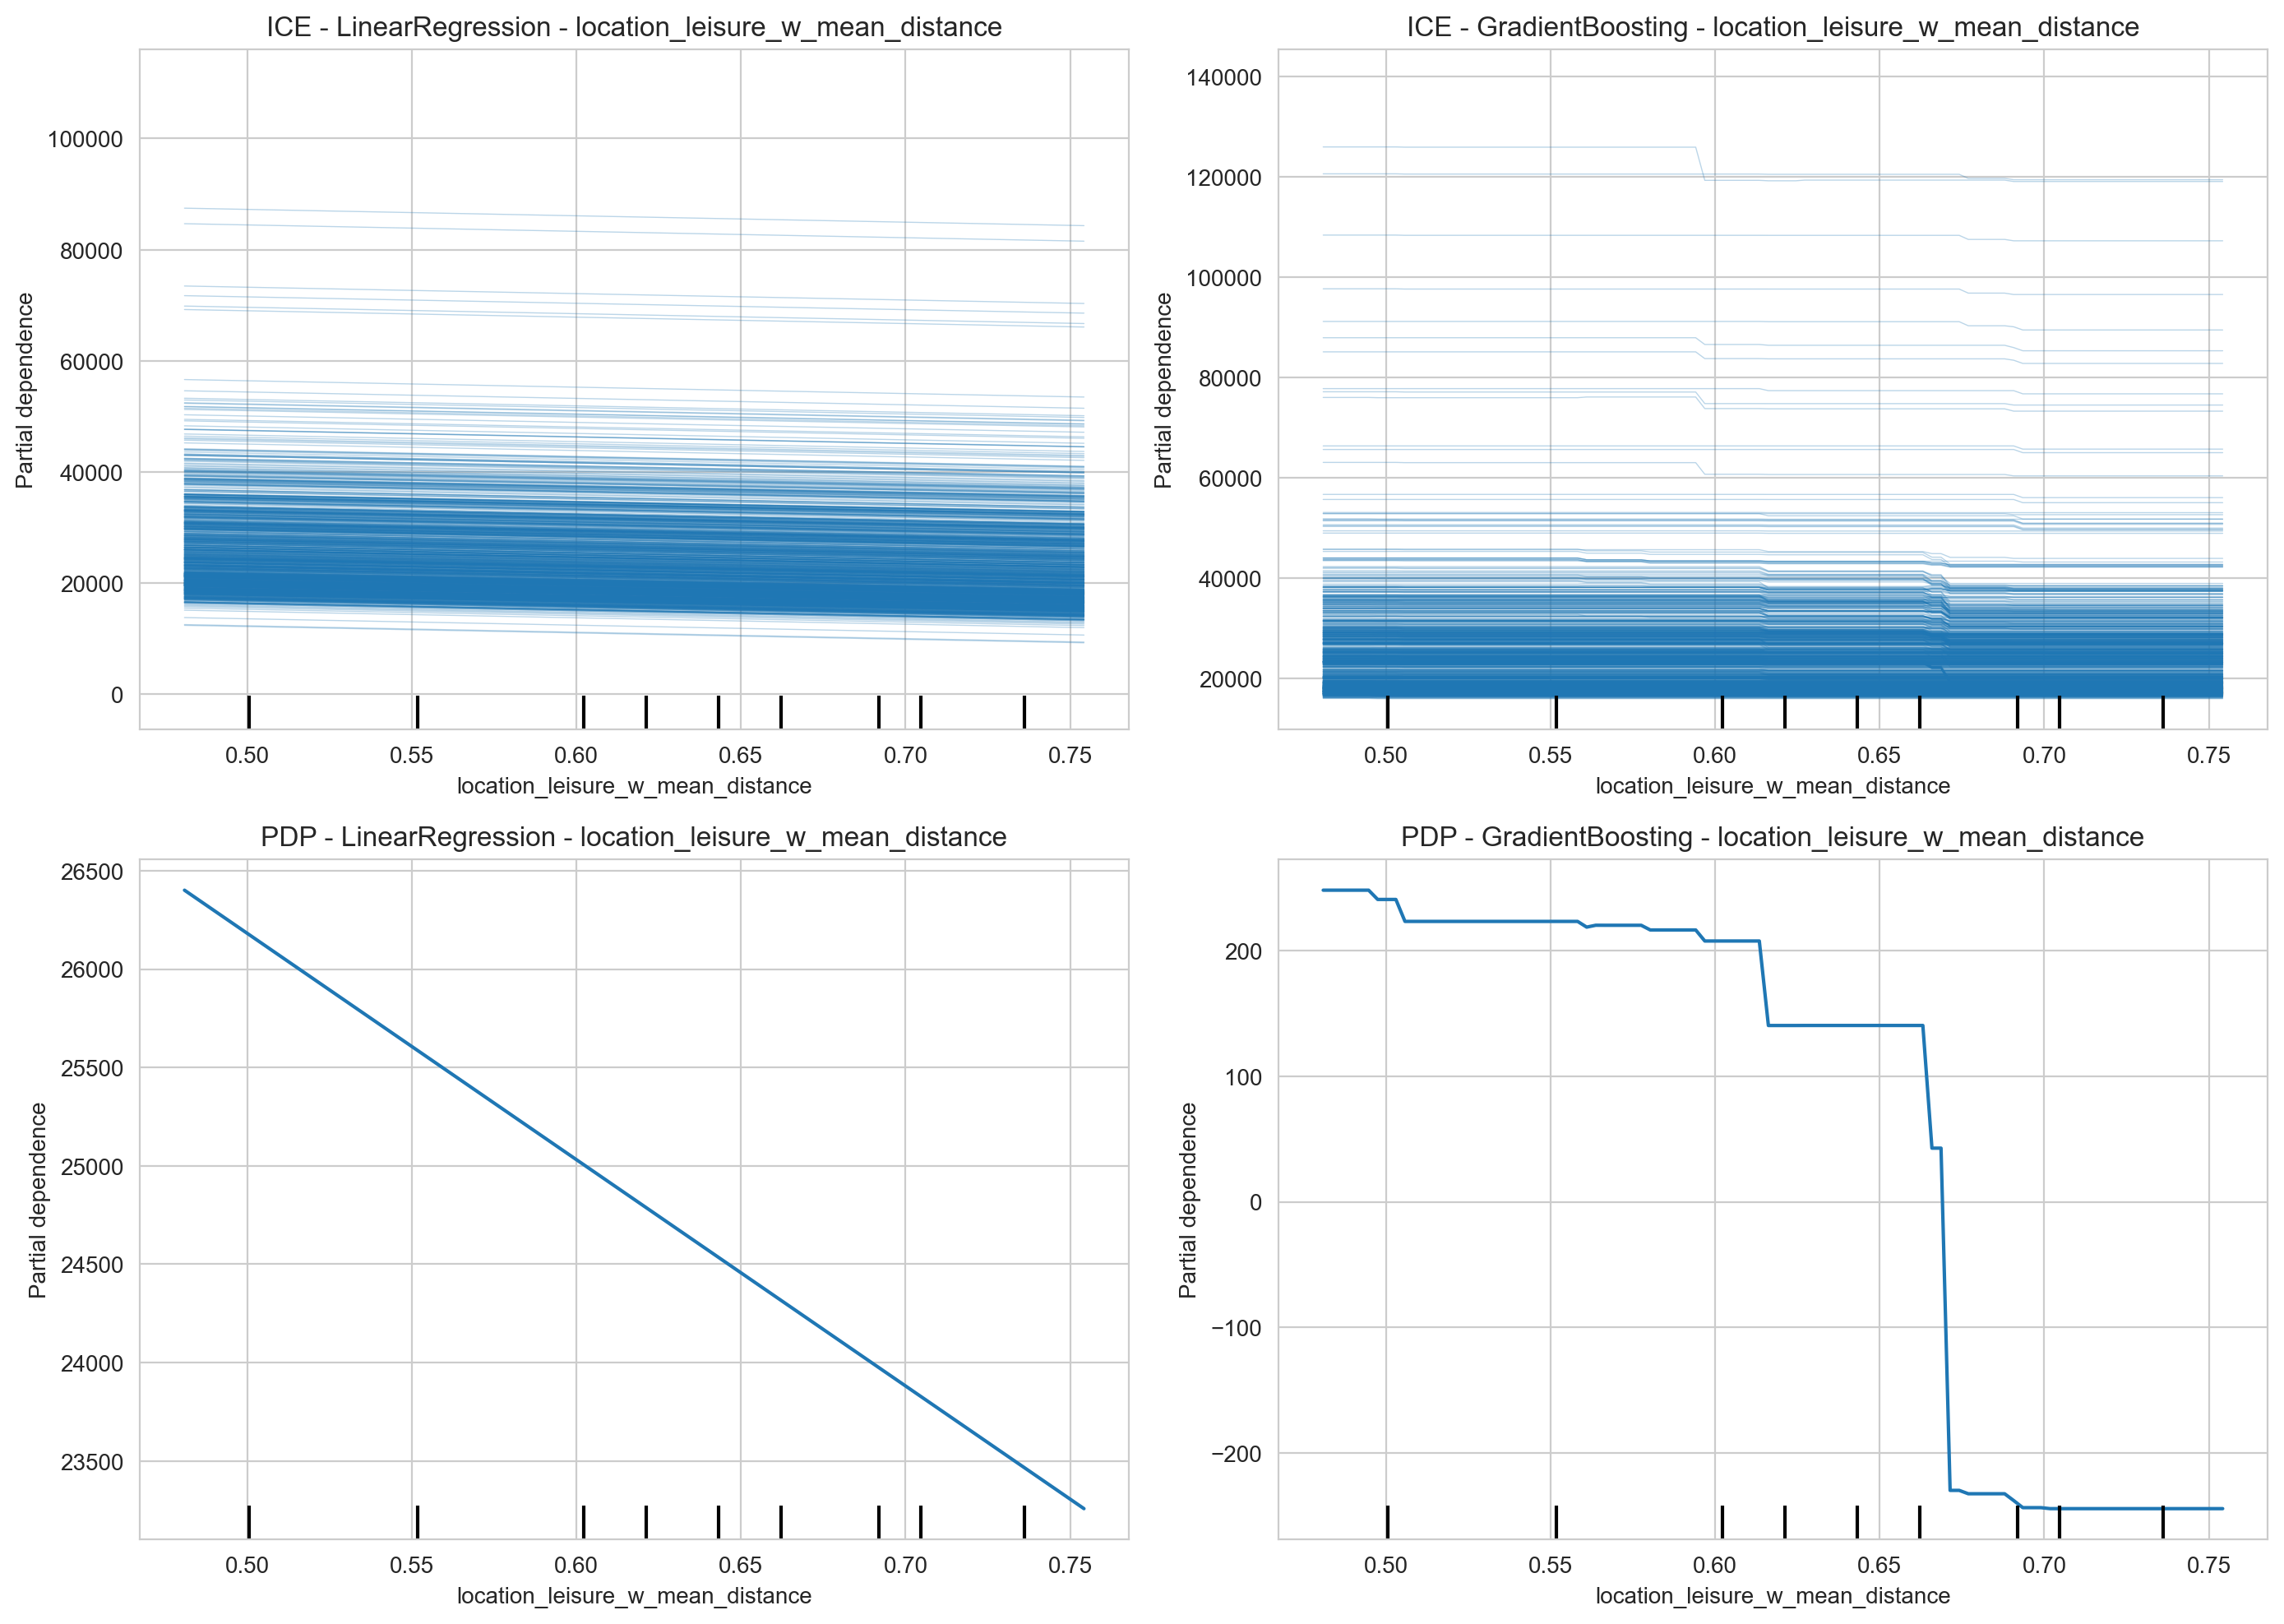

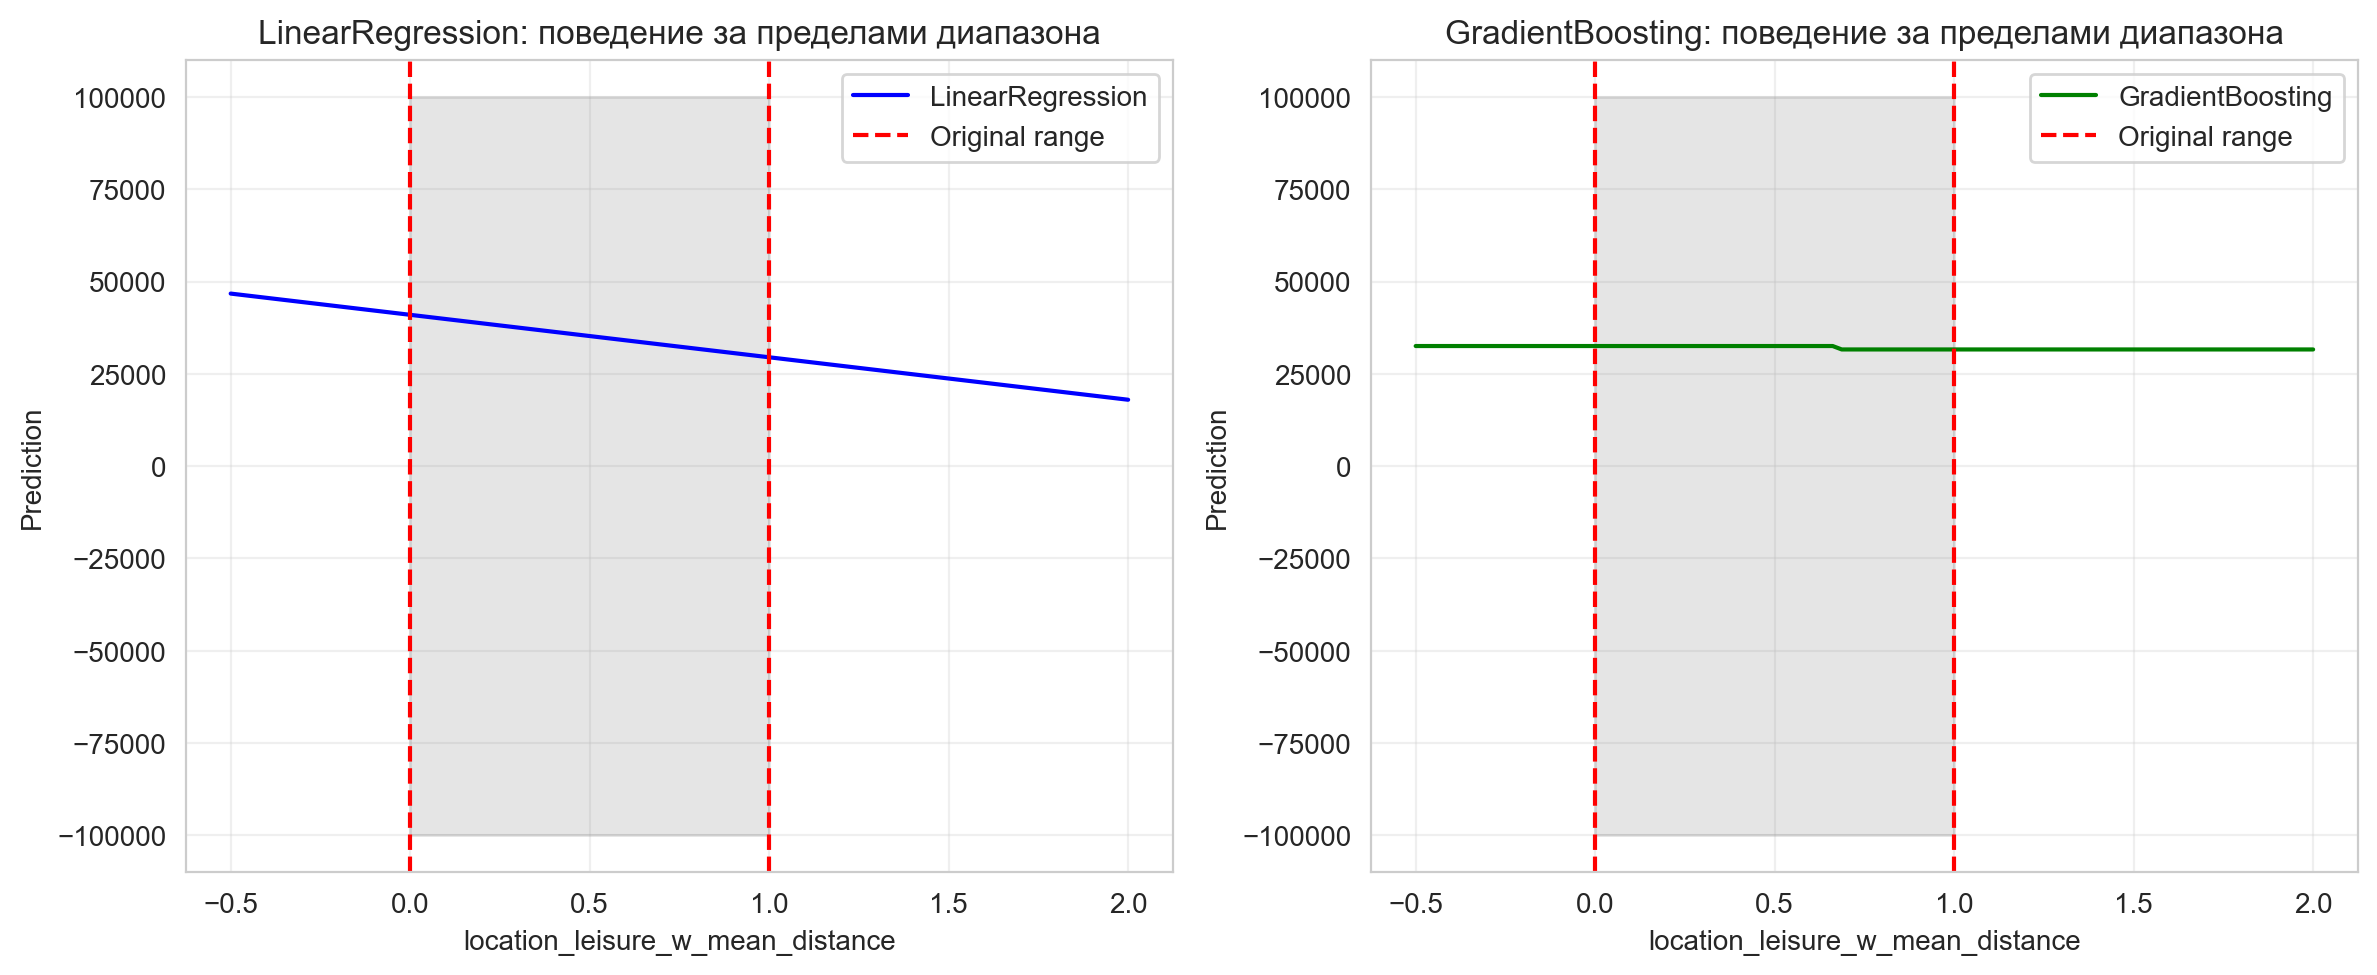

In [38]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

gb = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=100)
gb.fit(X_train_scaled, y_train)

feature_to_analyze = 'location_leisure_w_mean_distance'
feature_idx = feature_names.index(feature_to_analyze)

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx], kind='individual', ax=axes[0, 0])
axes[0, 0].set_title(f'ICE - LinearRegression - {feature_to_analyze}')

PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx], kind='individual', ax=axes[0, 1])
axes[0, 1].set_title(f'ICE - GradientBoosting - {feature_to_analyze}')

PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx], kind='average', ax=axes[1, 0])
axes[1, 0].set_title(f'PDP - LinearRegression - {feature_to_analyze}')

PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx], kind='average', ax=axes[1, 1])
axes[1, 1].set_title(f'PDP - GradientBoosting - {feature_to_analyze}')

plt.tight_layout()
plt.show()

original_min = X_train_df[feature_to_analyze].min()
original_max = X_train_df[feature_to_analyze].max()

X_test_outliers = X_test_df.copy()
outlier_values = [-0.5, -0.3, 1.3, 1.5, 2.0]

for outlier_val in outlier_values:
    X_test_outliers_single = X_test_df.copy()
    X_test_outliers_single[feature_to_analyze] = outlier_val

    lr_pred = lr.predict(X_test_outliers_single)
    gb_pred = gb.predict(X_test_outliers_single)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_range = np.linspace(-0.5, 2.0, 100)
X_temp = X_test_df.iloc[0:1].copy()

lr_preds = []
gb_preds = []
for val in x_range:
    X_temp[feature_to_analyze] = val
    lr_preds.append(lr.predict(X_temp)[0])
    gb_preds.append(gb.predict(X_temp)[0])

axes[0].plot(x_range, lr_preds, 'b-', label='LinearRegression')
axes[0].axvline(x=original_min, color='red', linestyle='--', label='Original range')
axes[0].axvline(x=original_max, color='red', linestyle='--')
axes[0].fill_between([original_min, original_max], -100000, 100000, alpha=0.2, color='gray')
axes[0].set_xlabel(feature_to_analyze)
axes[0].set_ylabel('Prediction')
axes[0].set_title('LinearRegression: поведение за пределами диапазона')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_range, gb_preds, 'g-', label='GradientBoosting')
axes[1].axvline(x=original_min, color='red', linestyle='--', label='Original range')
axes[1].axvline(x=original_max, color='red', linestyle='--')
axes[1].fill_between([original_min, original_max], -100000, 100000, alpha=0.2, color='gray')
axes[1].set_xlabel(feature_to_analyze)
axes[1].set_ylabel('Prediction')
axes[1].set_title('GradientBoosting: поведение за пределами диапазона')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

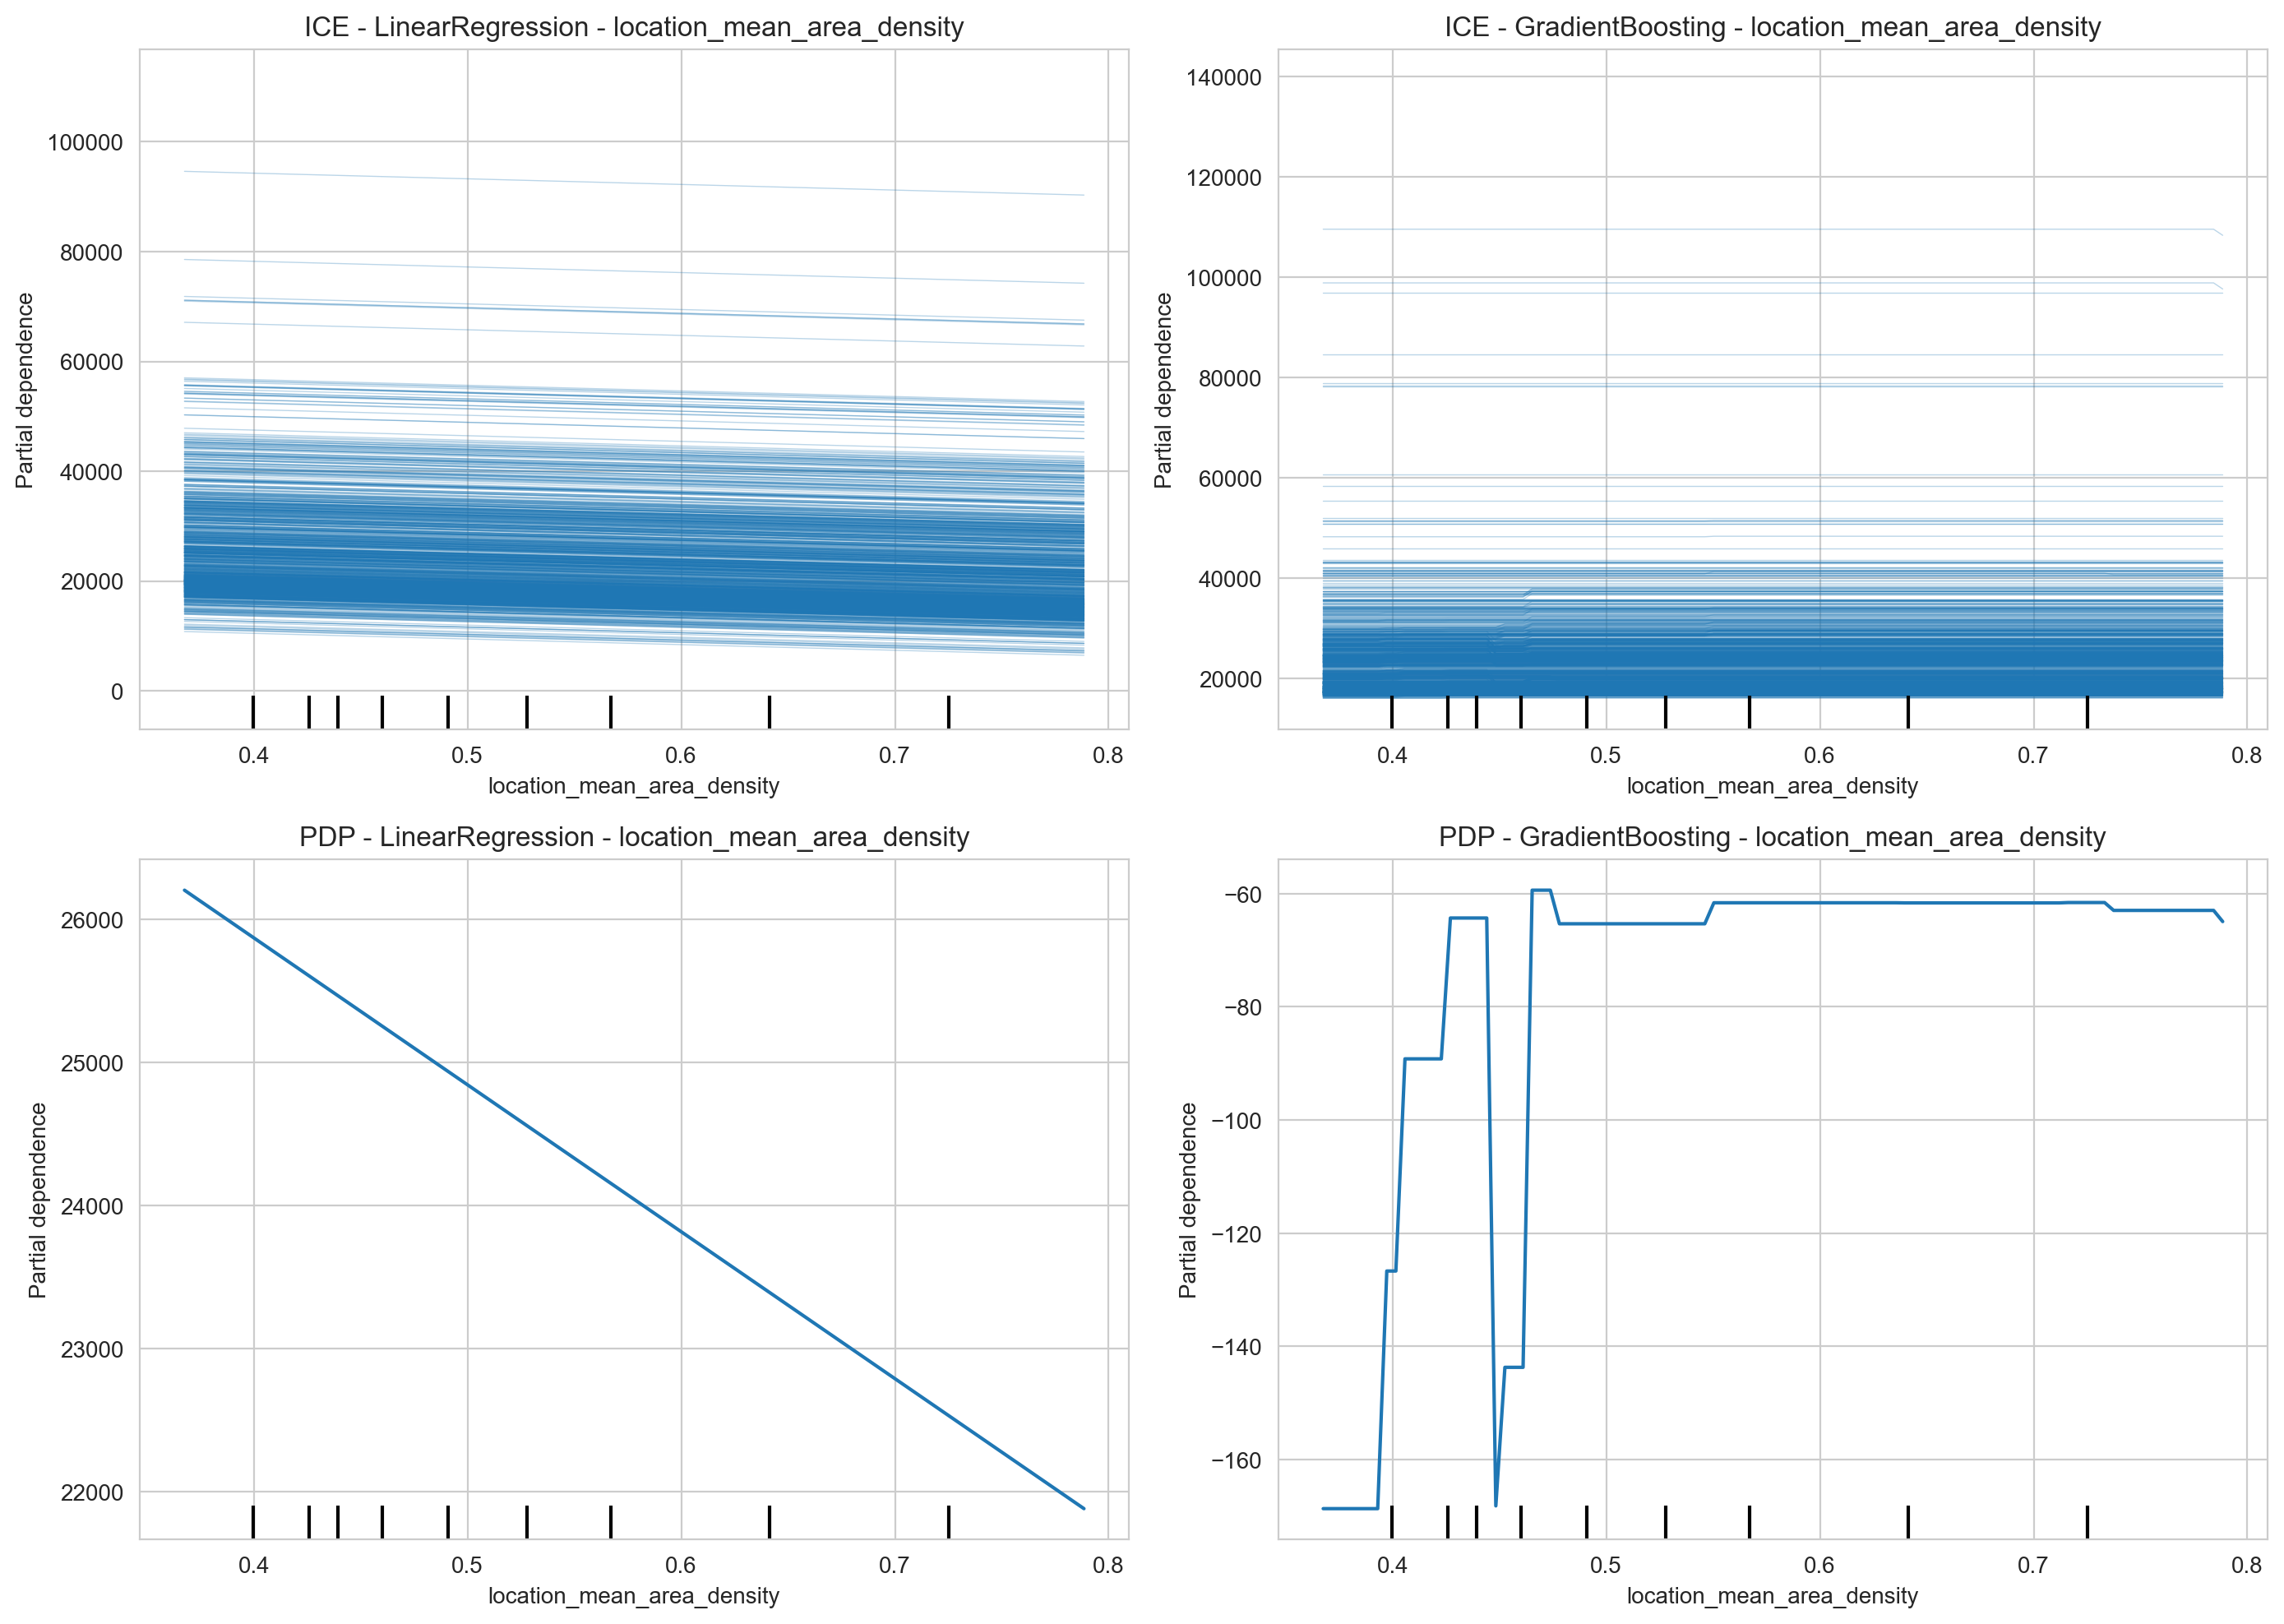

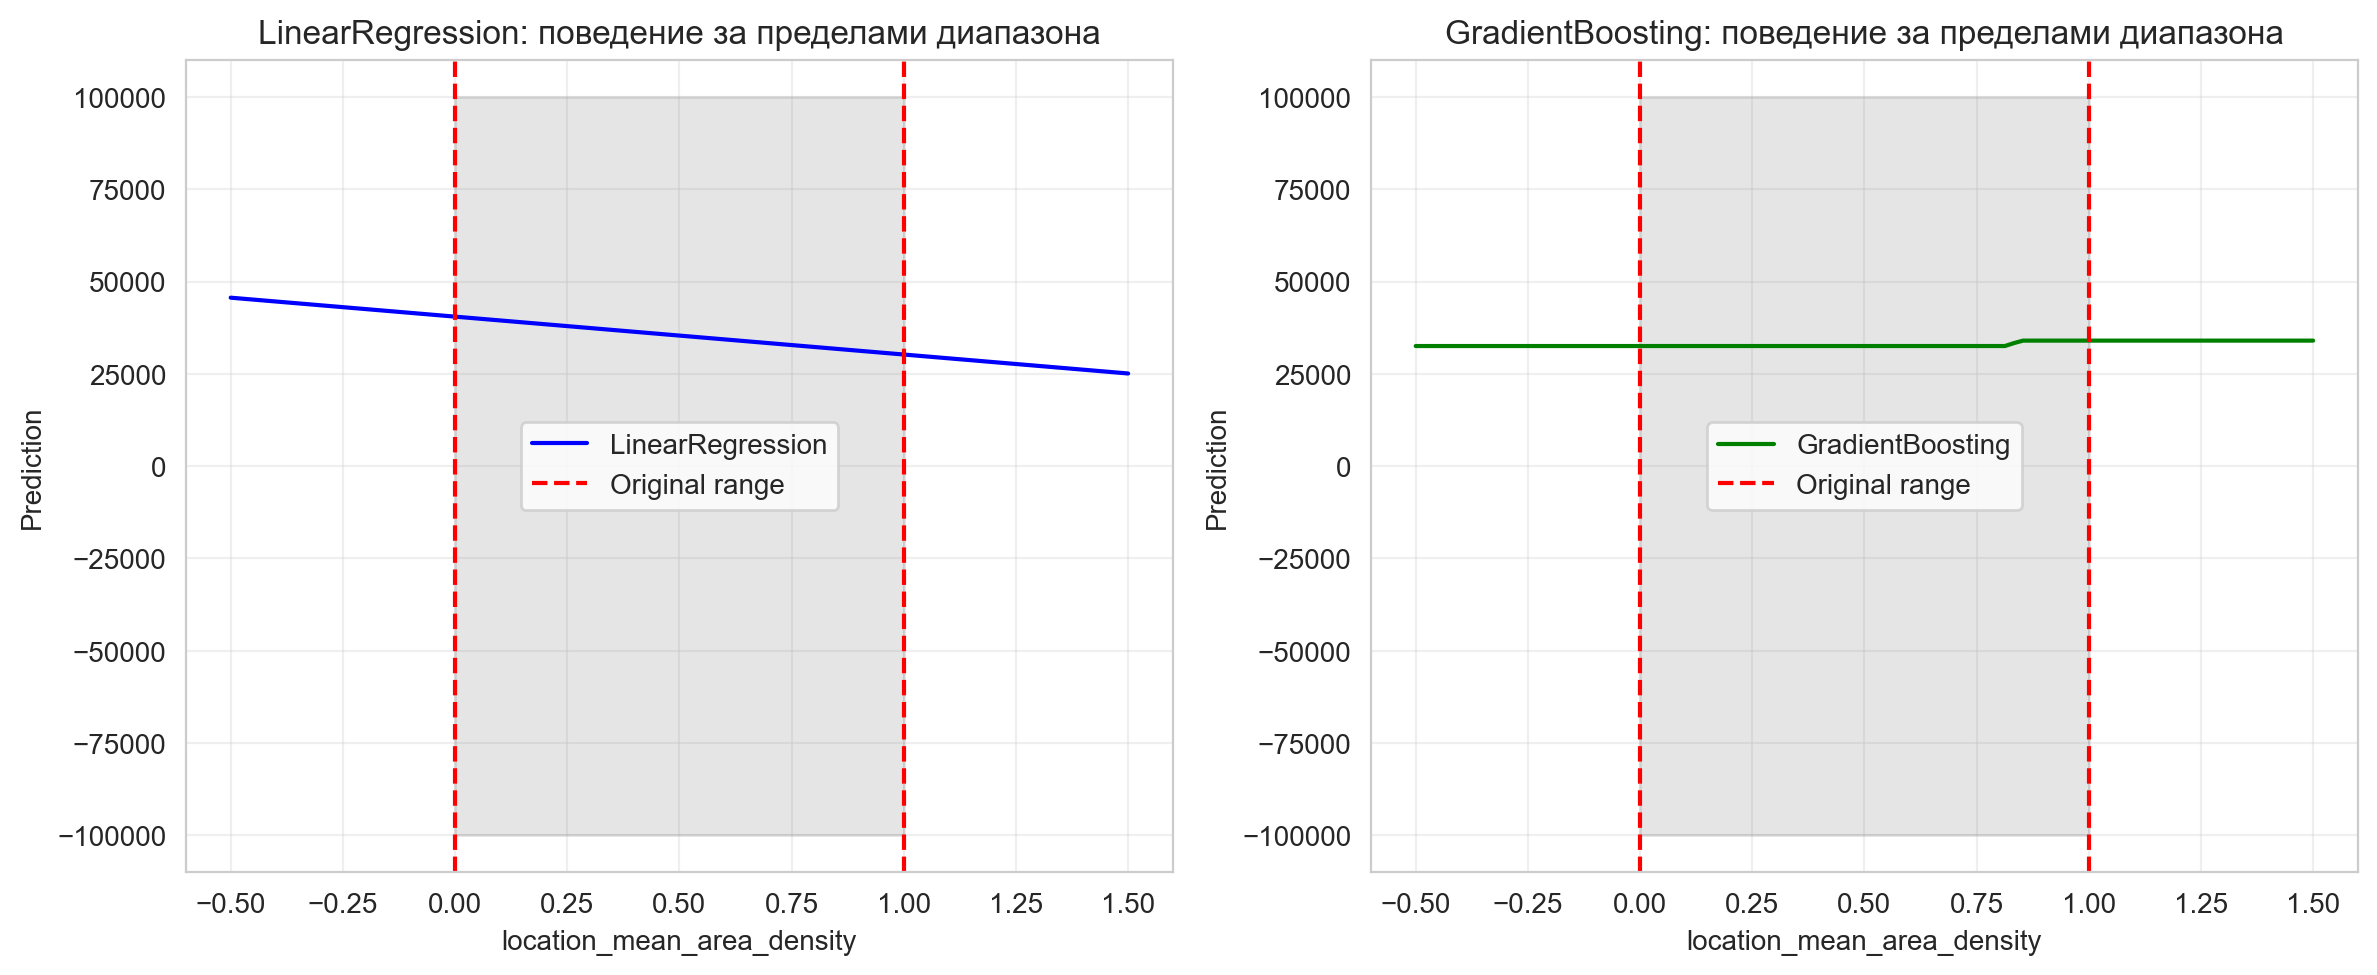

In [40]:
feature_to_analyze2 = 'location_mean_area_density'
feature_idx2 = feature_names.index(feature_to_analyze2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx2], kind='individual', ax=axes[0, 0])
axes[0, 0].set_title(f'ICE - LinearRegression - {feature_to_analyze2}')

PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx2], kind='individual', ax=axes[0, 1])
axes[0, 1].set_title(f'ICE - GradientBoosting - {feature_to_analyze2}')

PartialDependenceDisplay.from_estimator(lr, X_train_df, [feature_idx2], kind='average', ax=axes[1, 0])
axes[1, 0].set_title(f'PDP - LinearRegression - {feature_to_analyze2}')

PartialDependenceDisplay.from_estimator(gb, X_train_df, [feature_idx2], kind='average', ax=axes[1, 1])
axes[1, 1].set_title(f'PDP - GradientBoosting - {feature_to_analyze2}')

plt.tight_layout()
plt.show()

original_min2 = X_train_df[feature_to_analyze2].min()
original_max2 = X_train_df[feature_to_analyze2].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_range2 = np.linspace(original_min2 - 0.5, original_max2 + 0.5, 100)
X_temp2 = X_test_df.iloc[0:1].copy()

lr_preds2 = []
gb_preds2 = []
for val in x_range2:
    X_temp2[feature_to_analyze2] = val
    lr_preds2.append(lr.predict(X_temp2)[0])
    gb_preds2.append(gb.predict(X_temp2)[0])

axes[0].plot(x_range2, lr_preds2, 'b-', label='LinearRegression')
axes[0].axvline(x=original_min2, color='red', linestyle='--', label='Original range')
axes[0].axvline(x=original_max2, color='red', linestyle='--')
axes[0].fill_between([original_min2, original_max2], -100000, 100000, alpha=0.2, color='gray')
axes[0].set_xlabel(feature_to_analyze2)
axes[0].set_ylabel('Prediction')
axes[0].set_title('LinearRegression: поведение за пределами диапазона')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_range2, gb_preds2, 'g-', label='GradientBoosting')
axes[1].axvline(x=original_min2, color='red', linestyle='--', label='Original range')
axes[1].axvline(x=original_max2, color='red', linestyle='--')
axes[1].fill_between([original_min2, original_max2], -100000, 100000, alpha=0.2, color='gray')
axes[1].set_xlabel(feature_to_analyze2)
axes[1].set_ylabel('Prediction')
axes[1].set_title('GradientBoosting: поведение за пределами диапазона')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

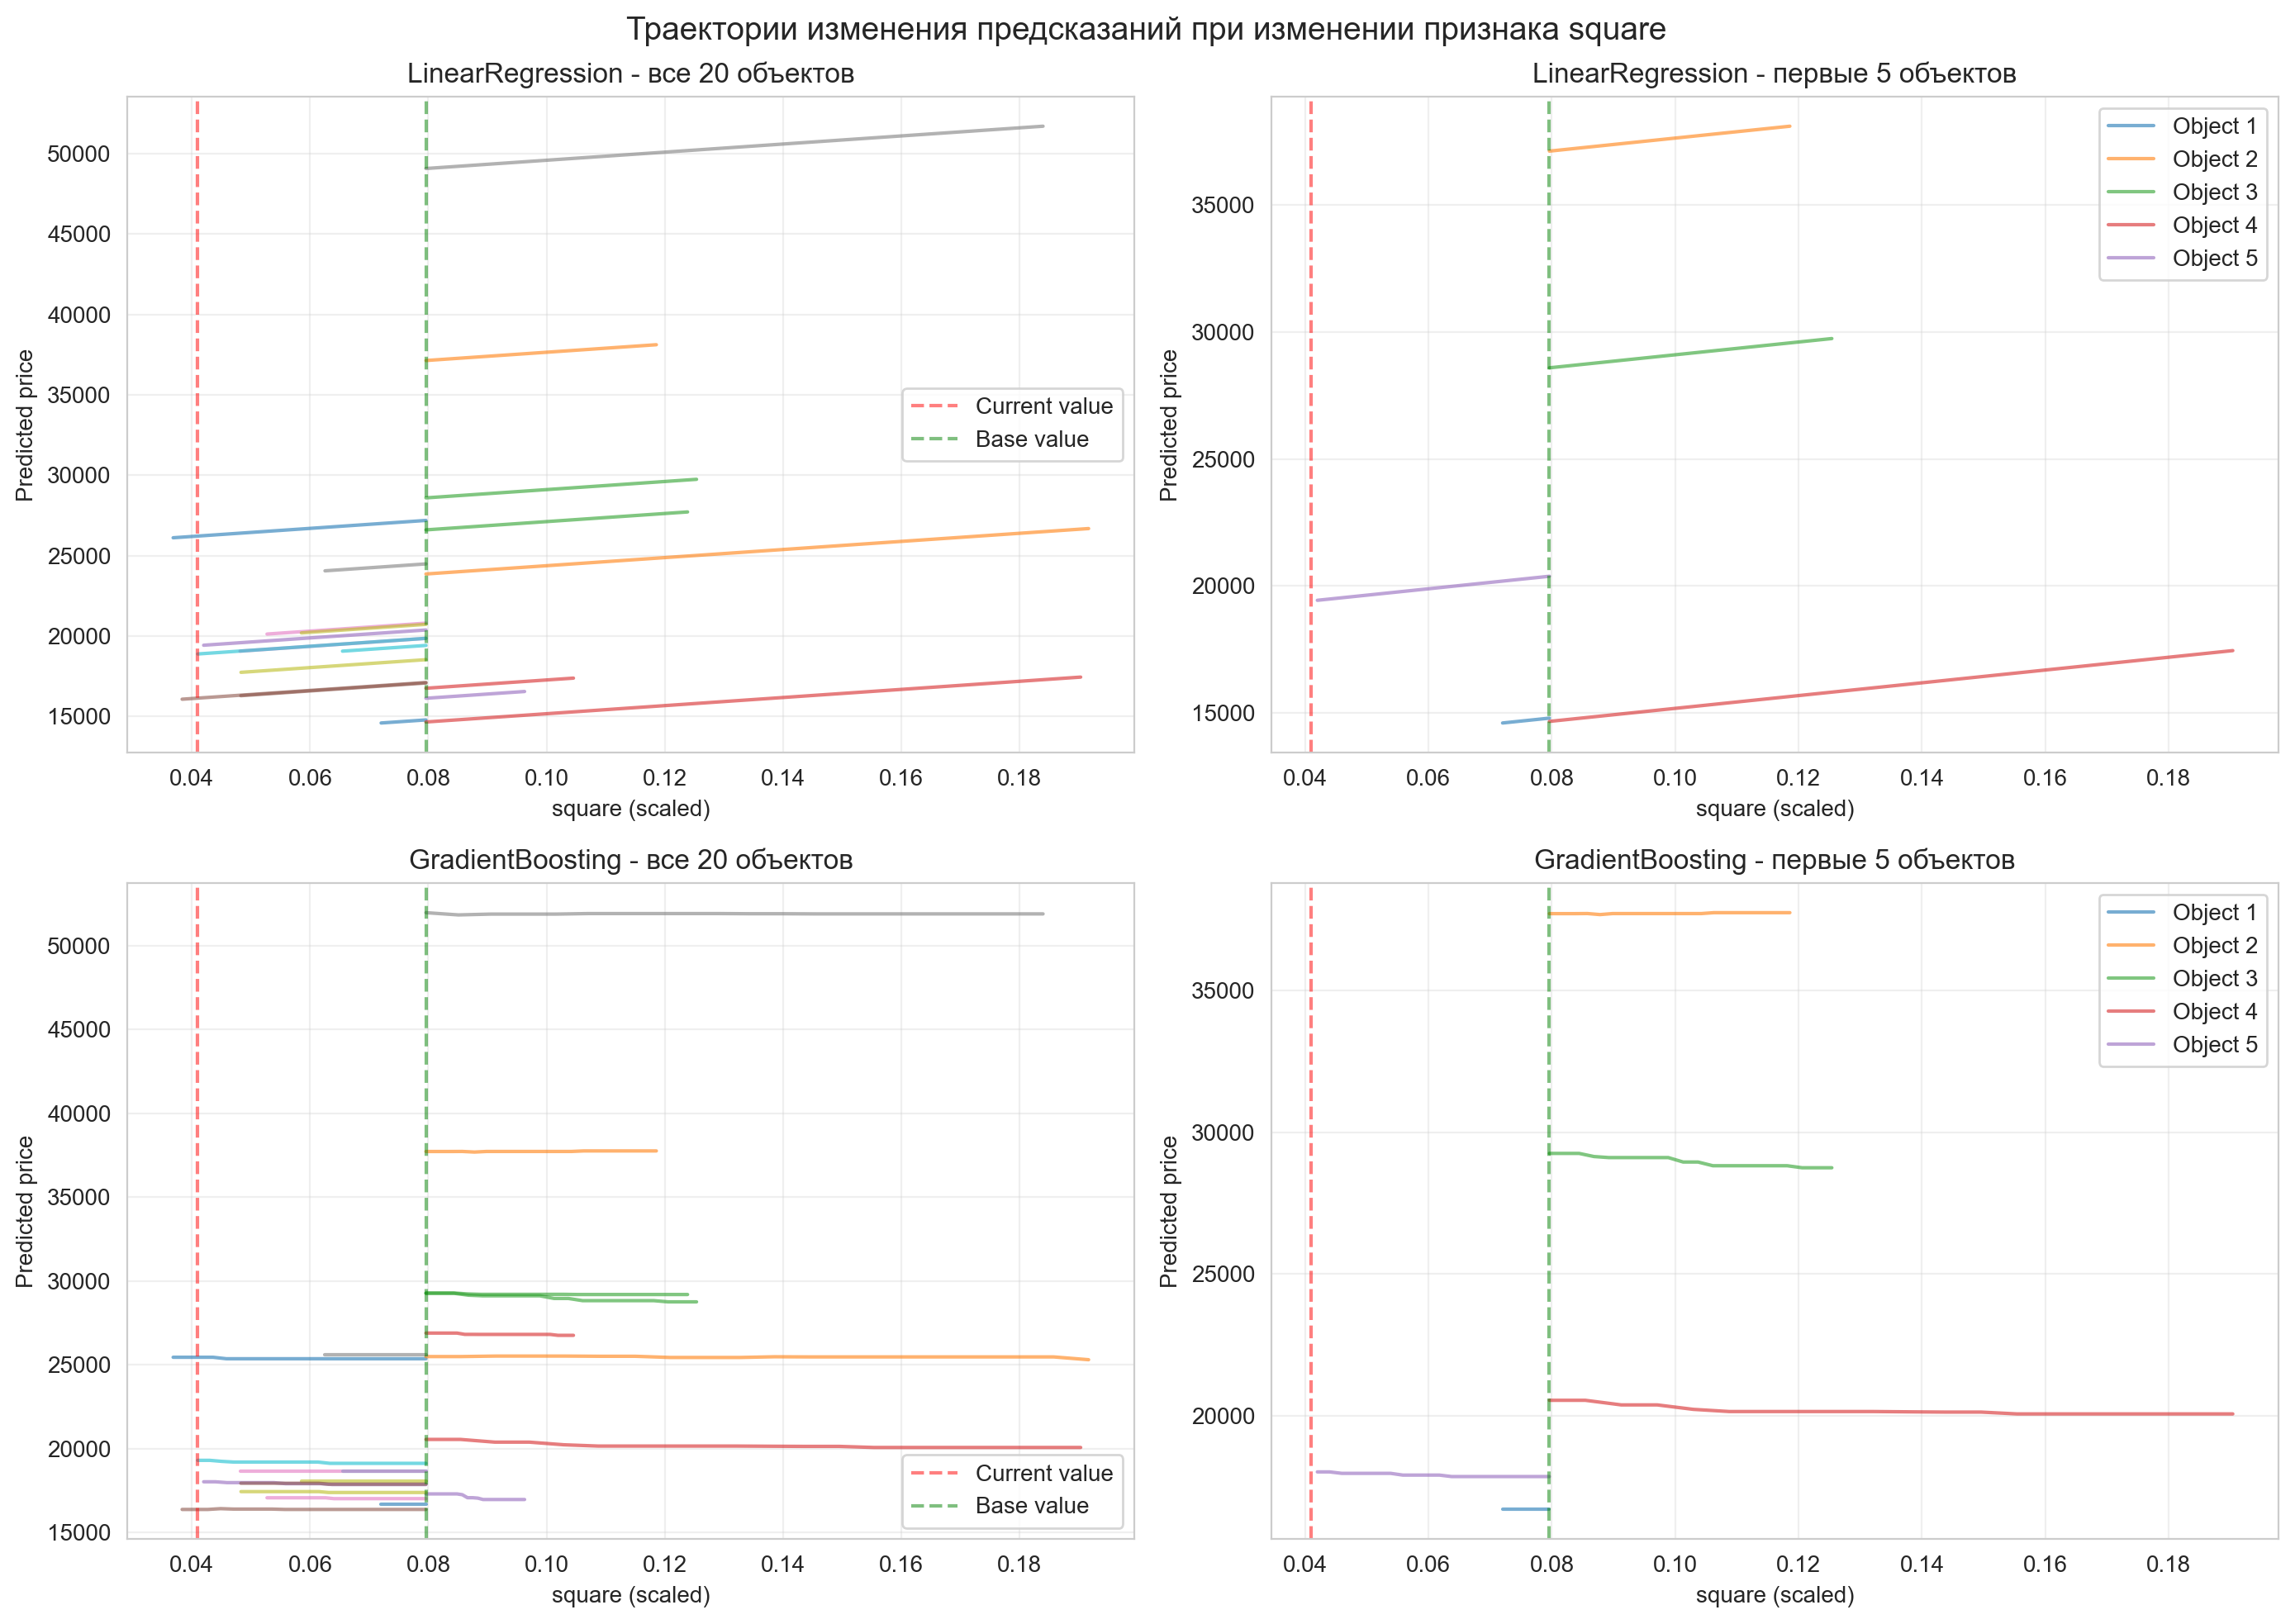

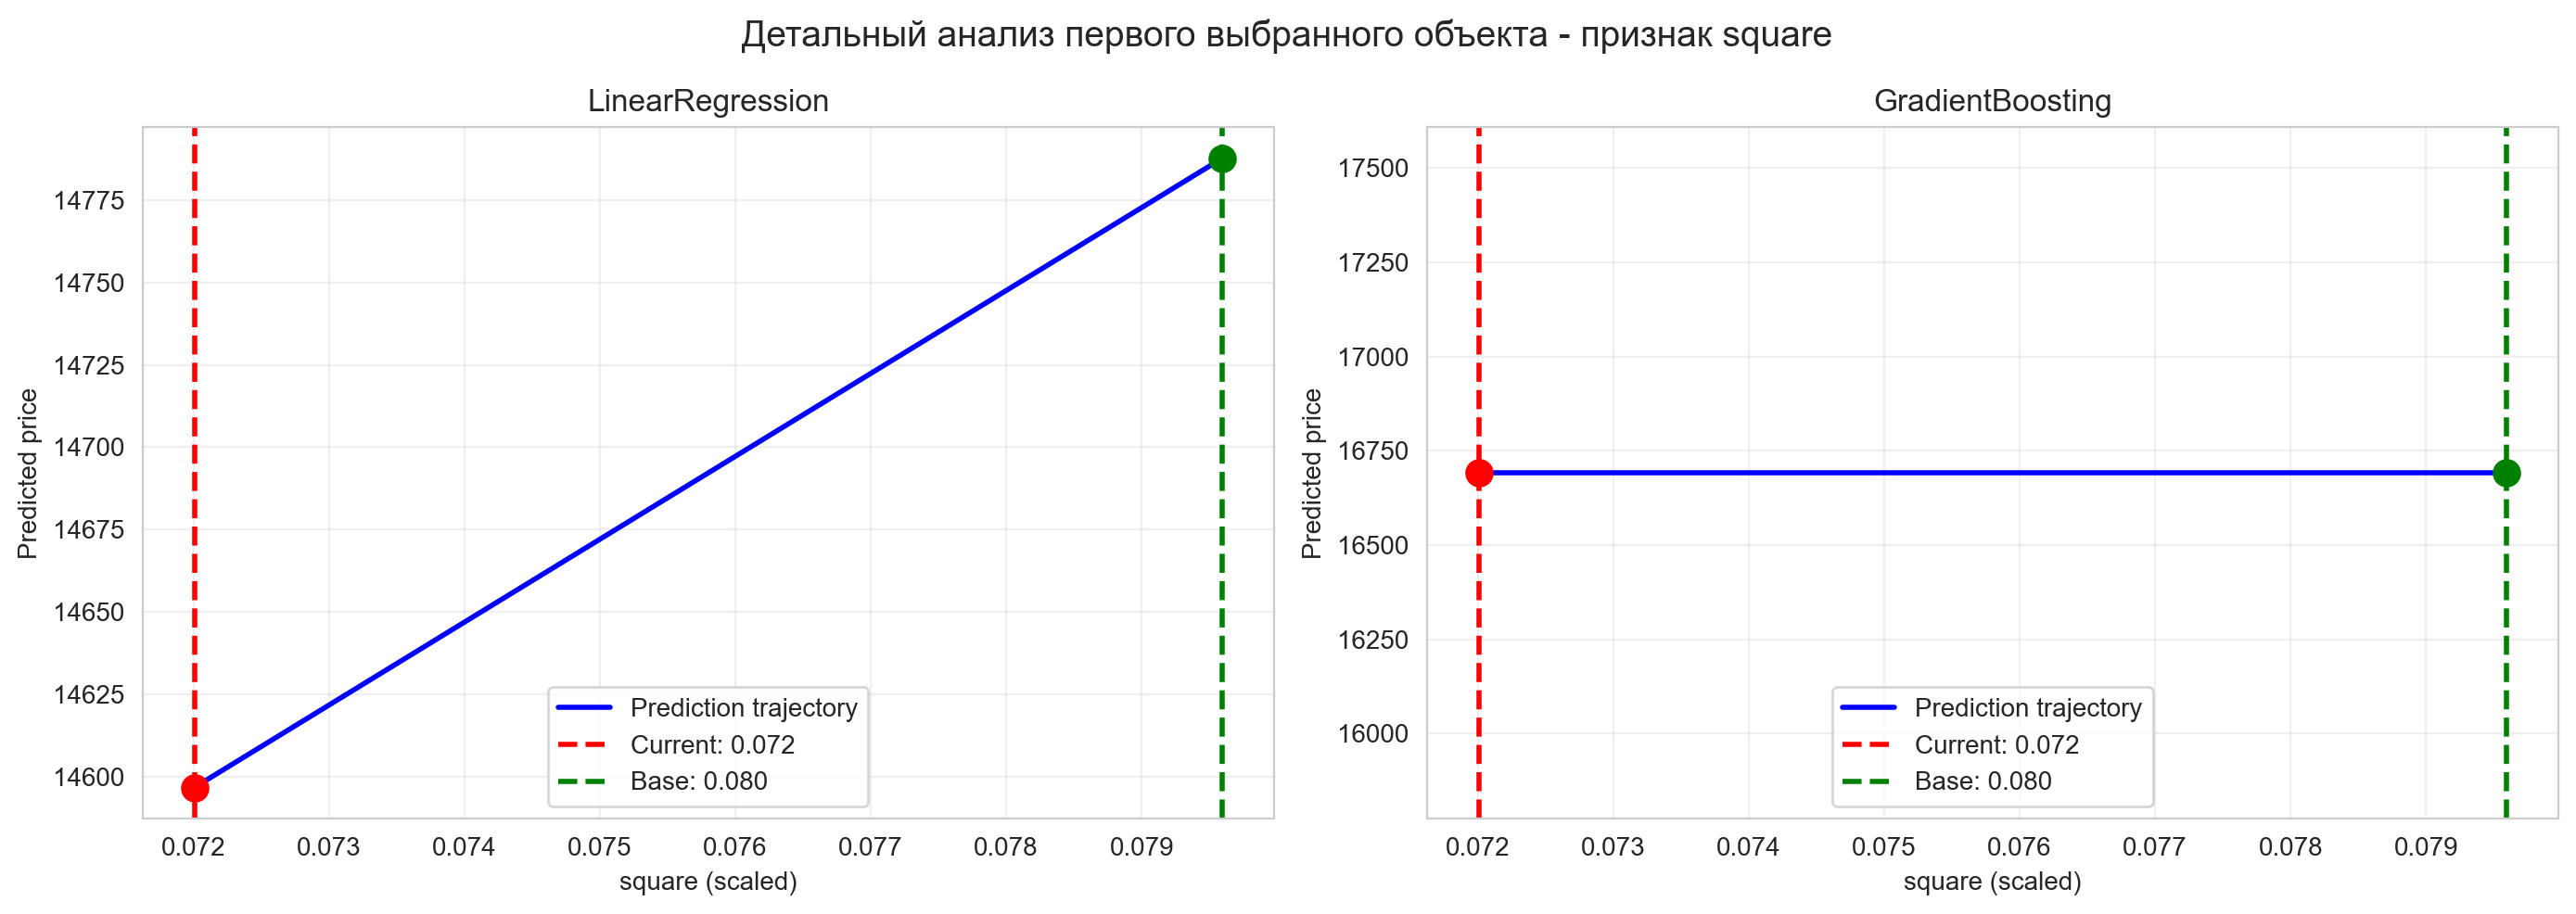

In [42]:
feature_to_analyze = 'square'

if feature_to_analyze in num_cols:
    feature_idx = num_cols.index(feature_to_analyze)
    base_value = X_train[feature_to_analyze].median()
elif cat_feature_names and feature_to_analyze in cat_feature_names:
    feature_idx = cat_feature_names.index(feature_to_analyze) + len(num_cols)
    base_value = 0.5
else:
    raise ValueError(f"Признак '{feature_to_analyze}' не найден")


def scale_single_feature(feature_idx, value):
    dummy = np.zeros((1, X_train_processed.shape[1]))
    dummy[0, feature_idx] = value
    dummy_scaled = scaler.transform(dummy)
    return dummy_scaled[0, feature_idx]


base_value_scaled = scale_single_feature(feature_idx, base_value)

n_objects = 20
n_steps = 20

np.random.seed(42)
indices = np.random.choice(len(X_test_scaled), n_objects, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Траектории изменения предсказаний при изменении признака {feature_to_analyze}', fontsize=14)

models_to_plot = [('LinearRegression', lr), ('GradientBoosting', gb)]

for idx, (model_name, model) in enumerate(models_to_plot):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]

    for i, test_idx in enumerate(indices):
        instance = X_test_scaled[test_idx].copy()
        current_val = instance[feature_idx]

        trajectory_preds = []
        trajectory_values = []
        values = np.linspace(current_val, base_value_scaled, n_steps)

        for val in values:
            instance[feature_idx] = val
            pred = model.predict(instance.reshape(1, -1))[0]
            trajectory_preds.append(pred)
            trajectory_values.append(val)

        ax1.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5)

        if i < 5:
            ax2.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5, label=f'Object {i + 1}')

    ax1.axvline(x=current_val, color='red', linestyle='--', alpha=0.5, label='Current value')
    ax1.axvline(x=base_value_scaled, color='green', linestyle='--', alpha=0.5, label='Base value')
    ax1.set_xlabel(f'{feature_to_analyze} (scaled)')
    ax1.set_ylabel('Predicted price')
    ax1.set_title(f'{model_name} - все {n_objects} объектов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.axvline(x=current_val, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(x=base_value_scaled, color='green', linestyle='--', alpha=0.5)
    ax2.set_xlabel(f'{feature_to_analyze} (scaled)')
    ax2.set_ylabel('Predicted price')
    ax2.set_title(f'{model_name} - первые 5 объектов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Детальный анализ первого выбранного объекта - признак {feature_to_analyze}', fontsize=14)

test_idx = indices[0]
instance = X_test_scaled[test_idx].copy()
current_val = instance[feature_idx]

for idx, (model_name, model) in enumerate(models_to_plot):
    values = np.linspace(current_val, base_value_scaled, n_steps)
    trajectory = []

    for val in values:
        instance_copy = instance.copy()
        instance_copy[feature_idx] = val
        pred = model.predict(instance_copy.reshape(1, -1))[0]
        trajectory.append(pred)

    axes[idx].plot(values, trajectory, 'b-', linewidth=2, label='Prediction trajectory')
    axes[idx].axvline(x=current_val, color='red', linestyle='--', linewidth=2, label=f'Current: {current_val:.3f}')
    axes[idx].axvline(x=base_value_scaled, color='green', linestyle='--', linewidth=2,
                      label=f'Base: {base_value_scaled:.3f}')

    pred_at_current = model.predict(instance.reshape(1, -1))[0]
    instance[feature_idx] = base_value_scaled
    pred_at_base = model.predict(instance.reshape(1, -1))[0]

    axes[idx].scatter(current_val, pred_at_current, color='red', s=100, zorder=5)
    axes[idx].scatter(base_value_scaled, pred_at_base, color='green', s=100, zorder=5)

    axes[idx].set_xlabel(f'{feature_to_analyze} (scaled)')
    axes[idx].set_ylabel('Predicted price')
    axes[idx].set_title(f'{model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

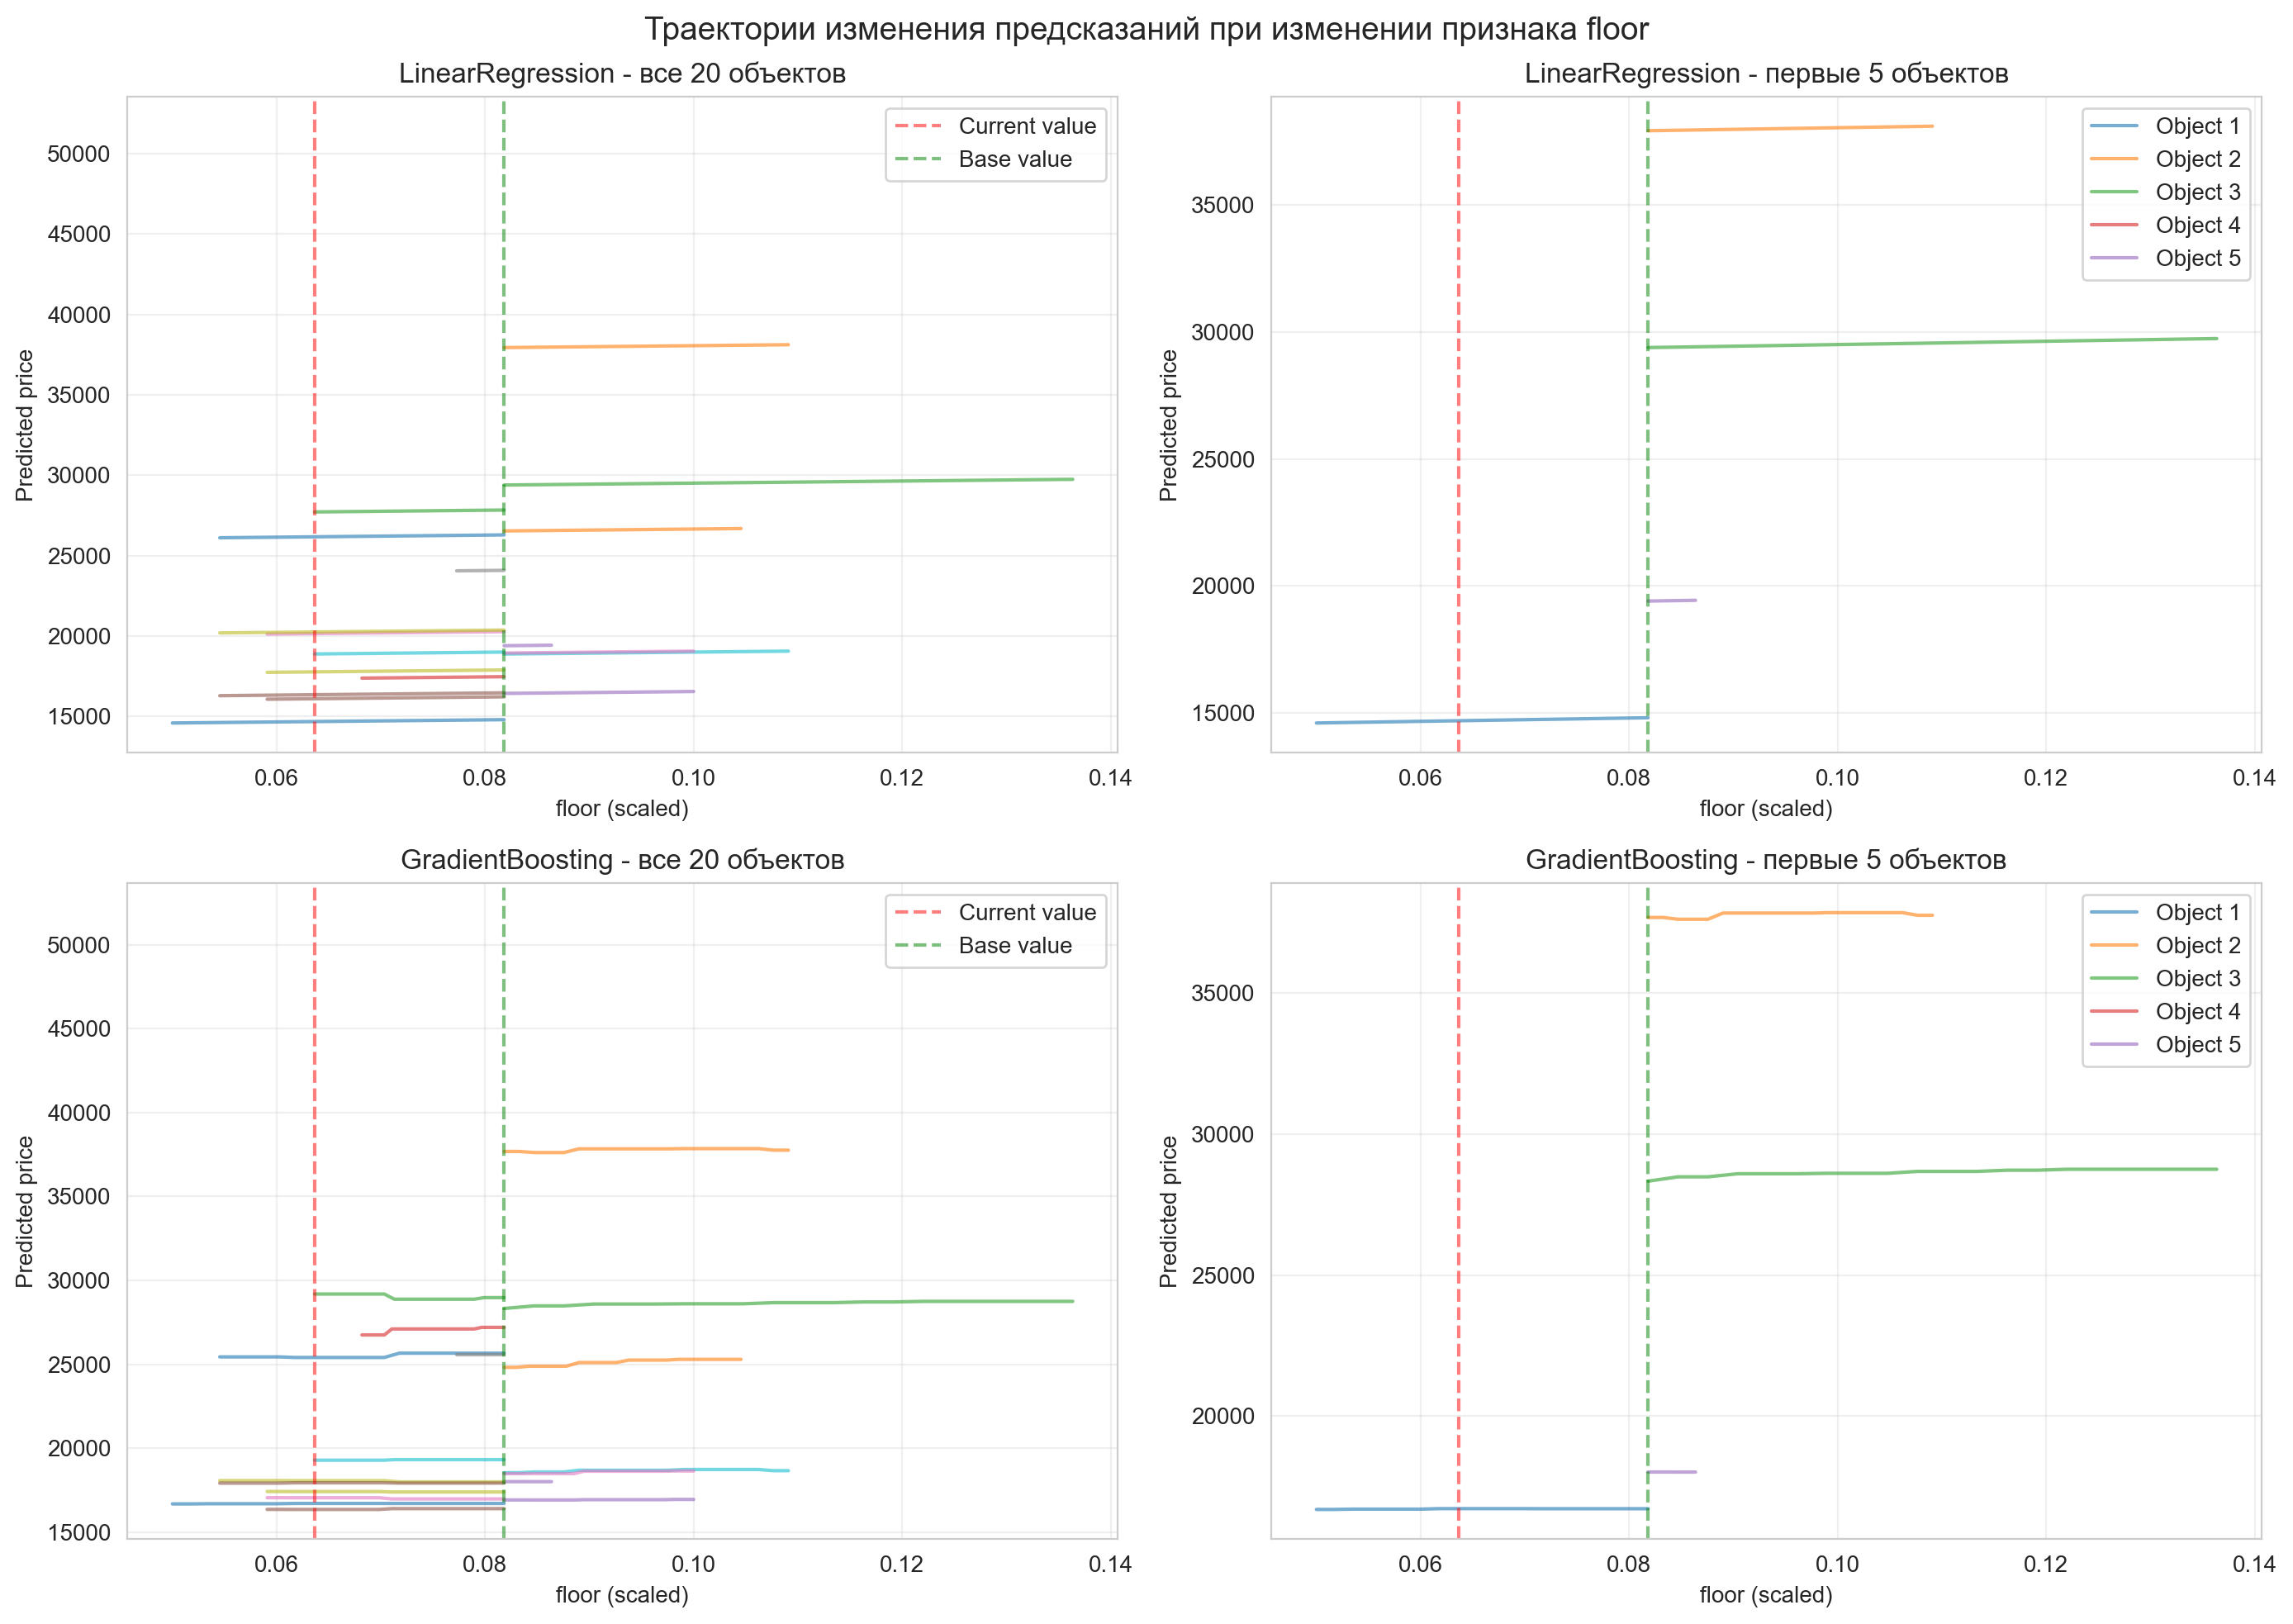

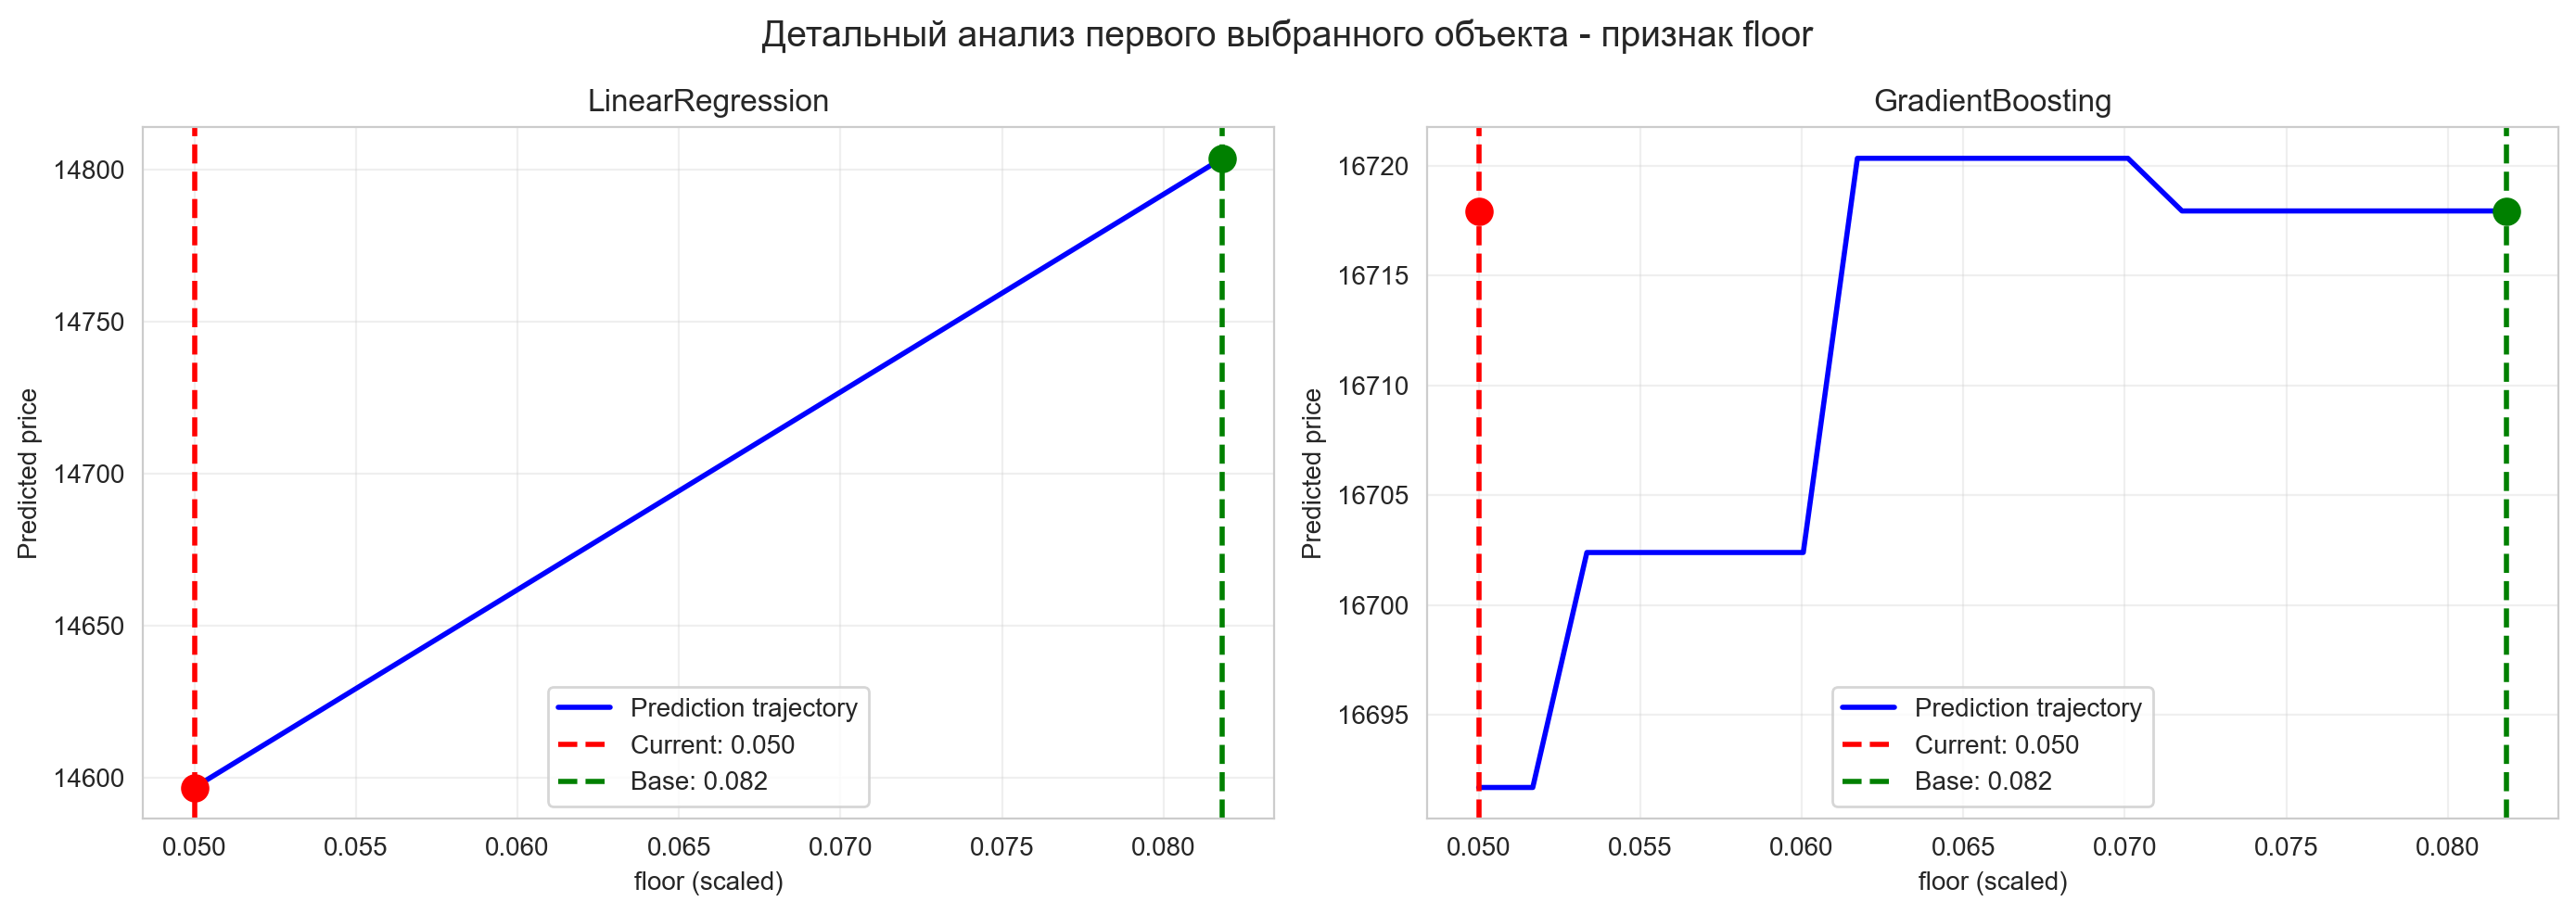

In [43]:
feature_to_analyze2 = 'floor'

if feature_to_analyze2 in num_cols:
    feature_idx2 = num_cols.index(feature_to_analyze2)
    base_value2 = X_train[feature_to_analyze2].median()
elif cat_feature_names and feature_to_analyze2 in cat_feature_names:
    feature_idx2 = cat_feature_names.index(feature_to_analyze2) + len(num_cols)
    base_value2 = 0.5
else:
    raise ValueError(f"Признак '{feature_to_analyze2}' не найден")

base_value_scaled2 = scale_single_feature(feature_idx2, base_value2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Траектории изменения предсказаний при изменении признака {feature_to_analyze2}', fontsize=14)

for idx, (model_name, model) in enumerate(models_to_plot):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]

    for i, test_idx in enumerate(indices):
        instance = X_test_scaled[test_idx].copy()
        current_val = instance[feature_idx2]

        trajectory_preds = []
        trajectory_values = []
        values = np.linspace(current_val, base_value_scaled2, n_steps)

        for val in values:
            instance[feature_idx2] = val
            pred = model.predict(instance.reshape(1, -1))[0]
            trajectory_preds.append(pred)
            trajectory_values.append(val)

        ax1.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5)

        if i < 5:
            ax2.plot(trajectory_values, trajectory_preds, alpha=0.6, linewidth=1.5, label=f'Object {i + 1}')

    ax1.axvline(x=current_val, color='red', linestyle='--', alpha=0.5, label='Current value')
    ax1.axvline(x=base_value_scaled2, color='green', linestyle='--', alpha=0.5, label='Base value')
    ax1.set_xlabel(f'{feature_to_analyze2} (scaled)')
    ax1.set_ylabel('Predicted price')
    ax1.set_title(f'{model_name} - все {n_objects} объектов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.axvline(x=current_val, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(x=base_value_scaled2, color='green', linestyle='--', alpha=0.5)
    ax2.set_xlabel(f'{feature_to_analyze2} (scaled)')
    ax2.set_ylabel('Predicted price')
    ax2.set_title(f'{model_name} - первые 5 объектов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Детальный анализ первого выбранного объекта - признак {feature_to_analyze2}', fontsize=14)

test_idx = indices[0]
instance = X_test_scaled[test_idx].copy()
current_val = instance[feature_idx2]

for idx, (model_name, model) in enumerate(models_to_plot):
    values = np.linspace(current_val, base_value_scaled2, n_steps)
    trajectory = []

    for val in values:
        instance_copy = instance.copy()
        instance_copy[feature_idx2] = val
        pred = model.predict(instance_copy.reshape(1, -1))[0]
        trajectory.append(pred)

    axes[idx].plot(values, trajectory, 'b-', linewidth=2, label='Prediction trajectory')
    axes[idx].axvline(x=current_val, color='red', linestyle='--', linewidth=2, label=f'Current: {current_val:.3f}')
    axes[idx].axvline(x=base_value_scaled2, color='green', linestyle='--', linewidth=2,
                      label=f'Base: {base_value_scaled2:.3f}')

    pred_at_current = model.predict(instance.reshape(1, -1))[0]
    instance[feature_idx2] = base_value_scaled2
    pred_at_base = model.predict(instance.reshape(1, -1))[0]

    axes[idx].scatter(current_val, pred_at_current, color='red', s=100, zorder=5)
    axes[idx].scatter(base_value_scaled2, pred_at_base, color='green', s=100, zorder=5)

    axes[idx].set_xlabel(f'{feature_to_analyze2} (scaled)')
    axes[idx].set_ylabel('Predicted price')
    axes[idx].set_title(f'{model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Discrete feature detected.


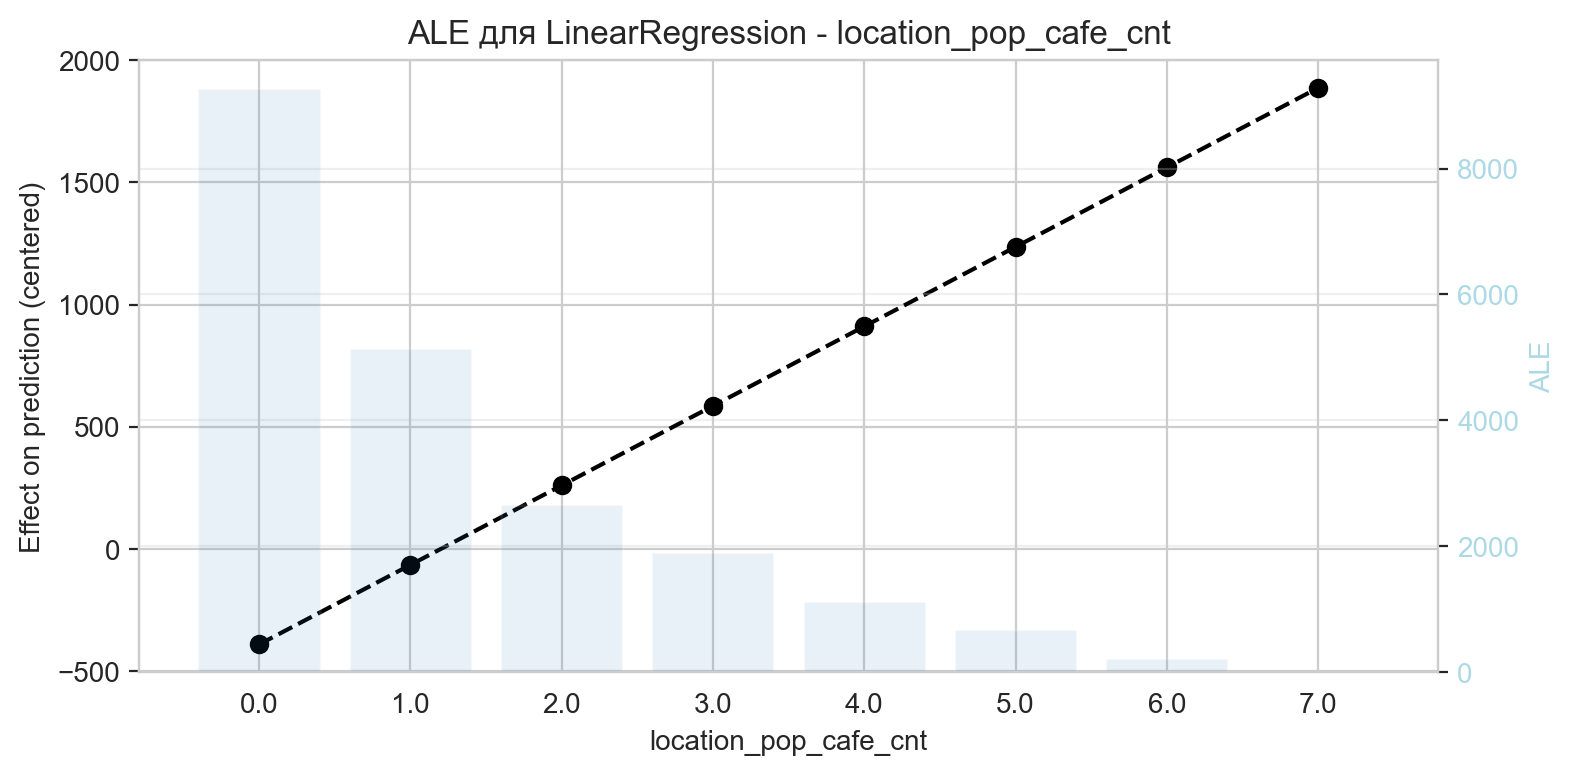

PyALE._ALE_generic:INFO: Discrete feature detected.


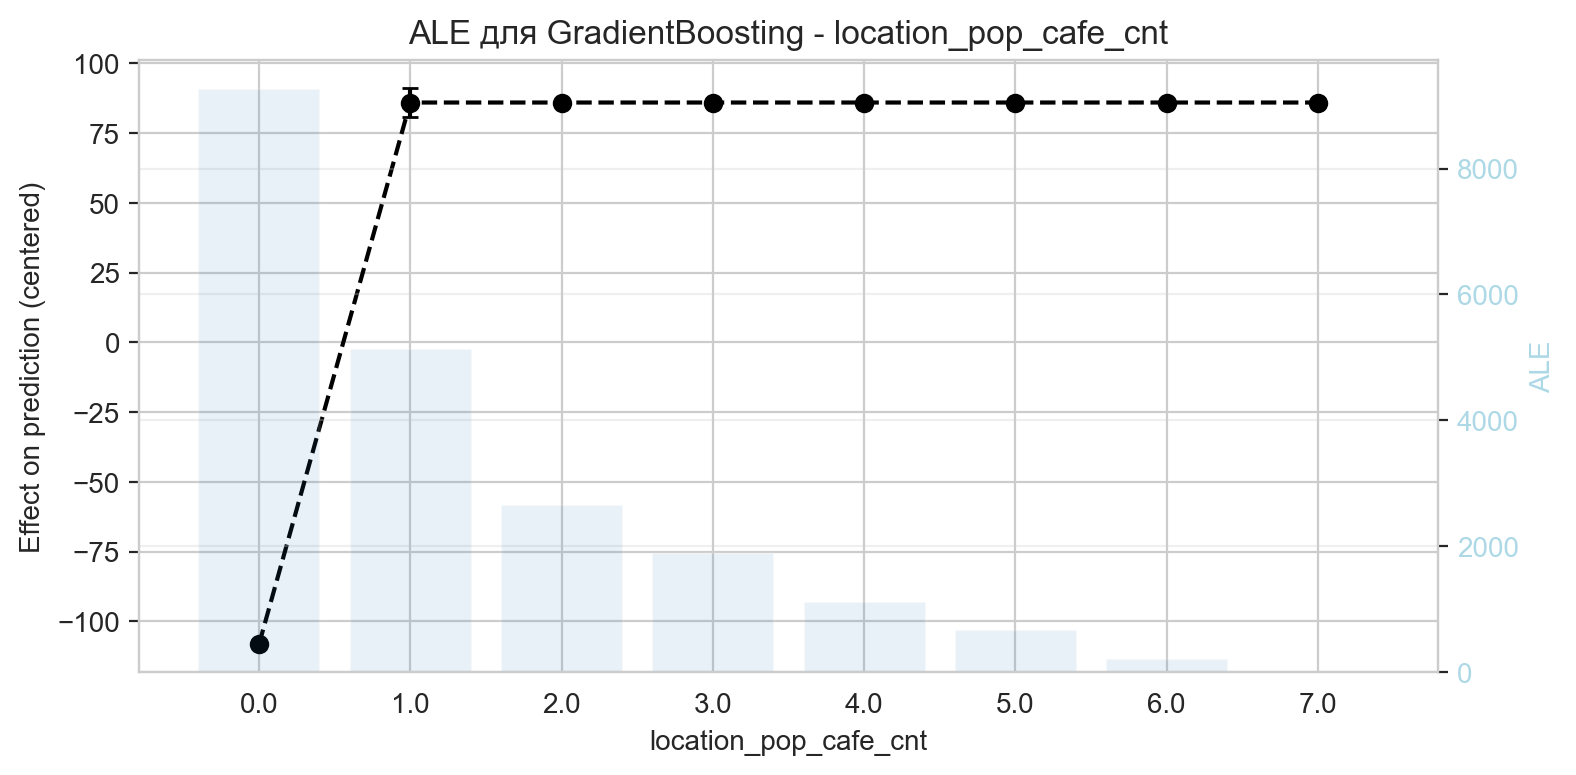

In [50]:
from PyALE import ale
import matplotlib.pyplot as plt

feature_to_analyze = 'location_pop_cafe_cnt'

X_train_original = pd.DataFrame(X_train_processed, columns=feature_names)

ale_lr = ale(
    X=X_train_original,
    model=lr,
    feature=[feature_to_analyze],
    grid_size=50
)

plt.title(f'ALE для LinearRegression - {feature_to_analyze}')
plt.xlabel(feature_to_analyze)
plt.ylabel('ALE')
plt.grid(True, alpha=0.3)
plt.show()

ale_gb = ale(
    X=X_train_original,
    model=gb,
    feature=[feature_to_analyze],
    grid_size=50
)

plt.title(f'ALE для GradientBoosting - {feature_to_analyze}')
plt.xlabel(feature_to_analyze)
plt.ylabel('ALE')
plt.grid(True, alpha=0.3)
plt.show()

PyALE._ALE_generic:INFO: Discrete feature detected.


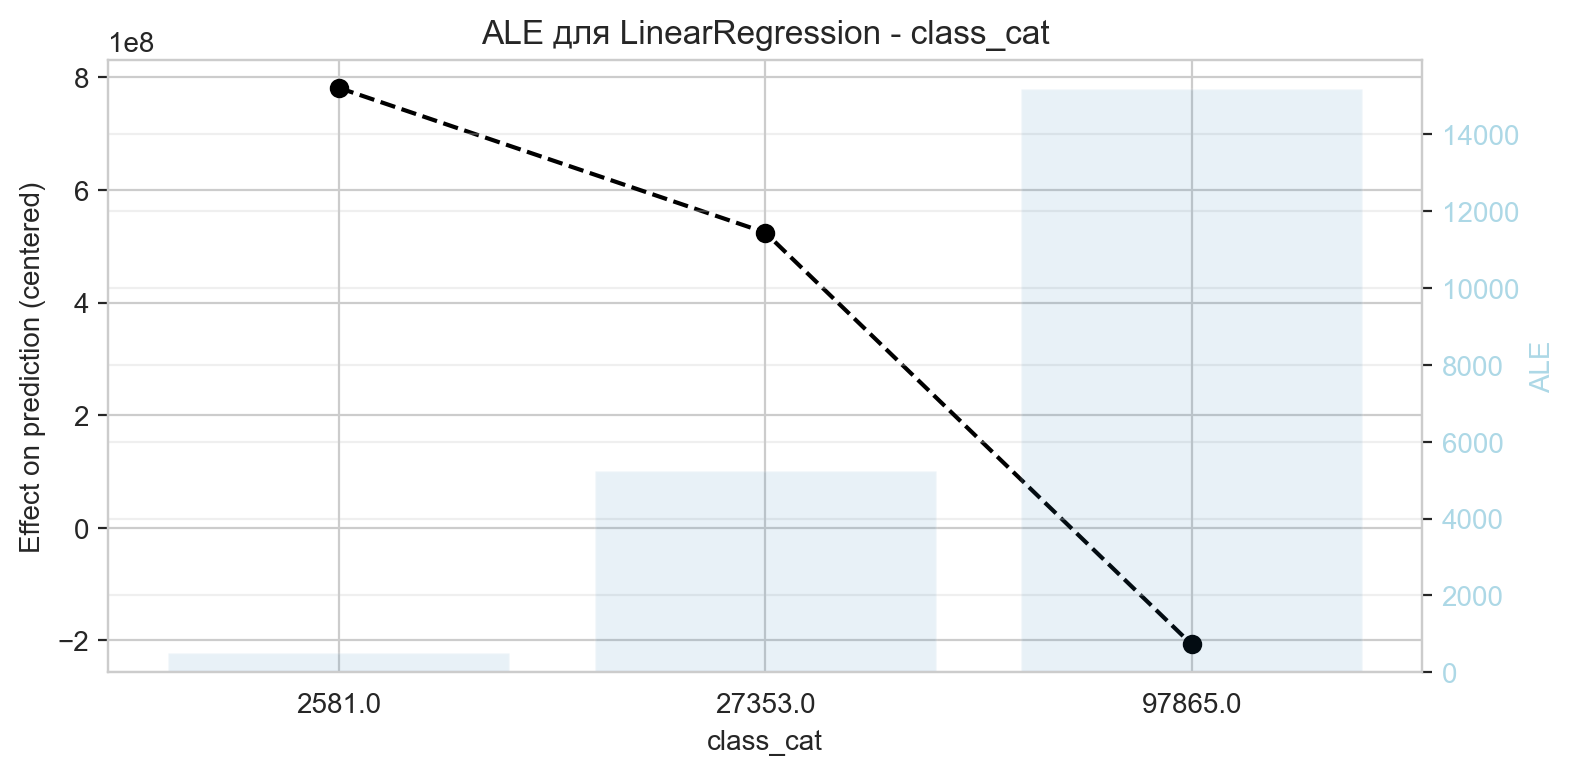

PyALE._ALE_generic:INFO: Discrete feature detected.


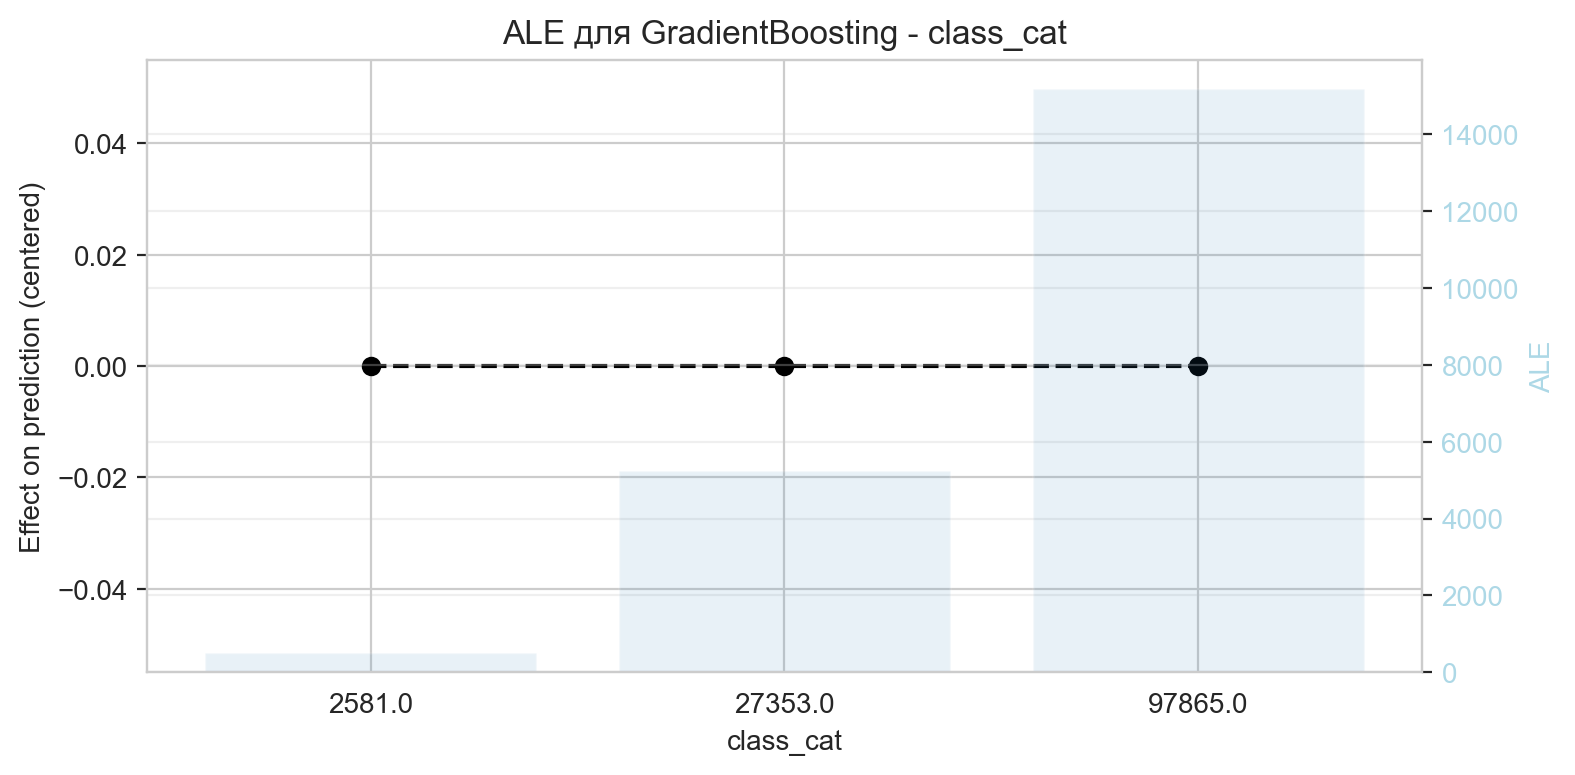

In [48]:
feature_to_analyze2 = 'class_cat'

ale_lr2 = ale(
    X=X_train_original,
    model=lr,
    feature=[feature_to_analyze2],
    grid_size=50
)

plt.title(f'ALE для LinearRegression - {feature_to_analyze2}')
plt.xlabel(feature_to_analyze2)
plt.ylabel('ALE')
plt.grid(True, alpha=0.3)
plt.show()

ale_gb2 = ale(
    X=X_train_original,
    model=gb,
    feature=[feature_to_analyze2],
    grid_size=50
)

plt.title(f'ALE для GradientBoosting - {feature_to_analyze2}')
plt.xlabel(feature_to_analyze2)
plt.ylabel('ALE')
plt.grid(True, alpha=0.3)
plt.show()

PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


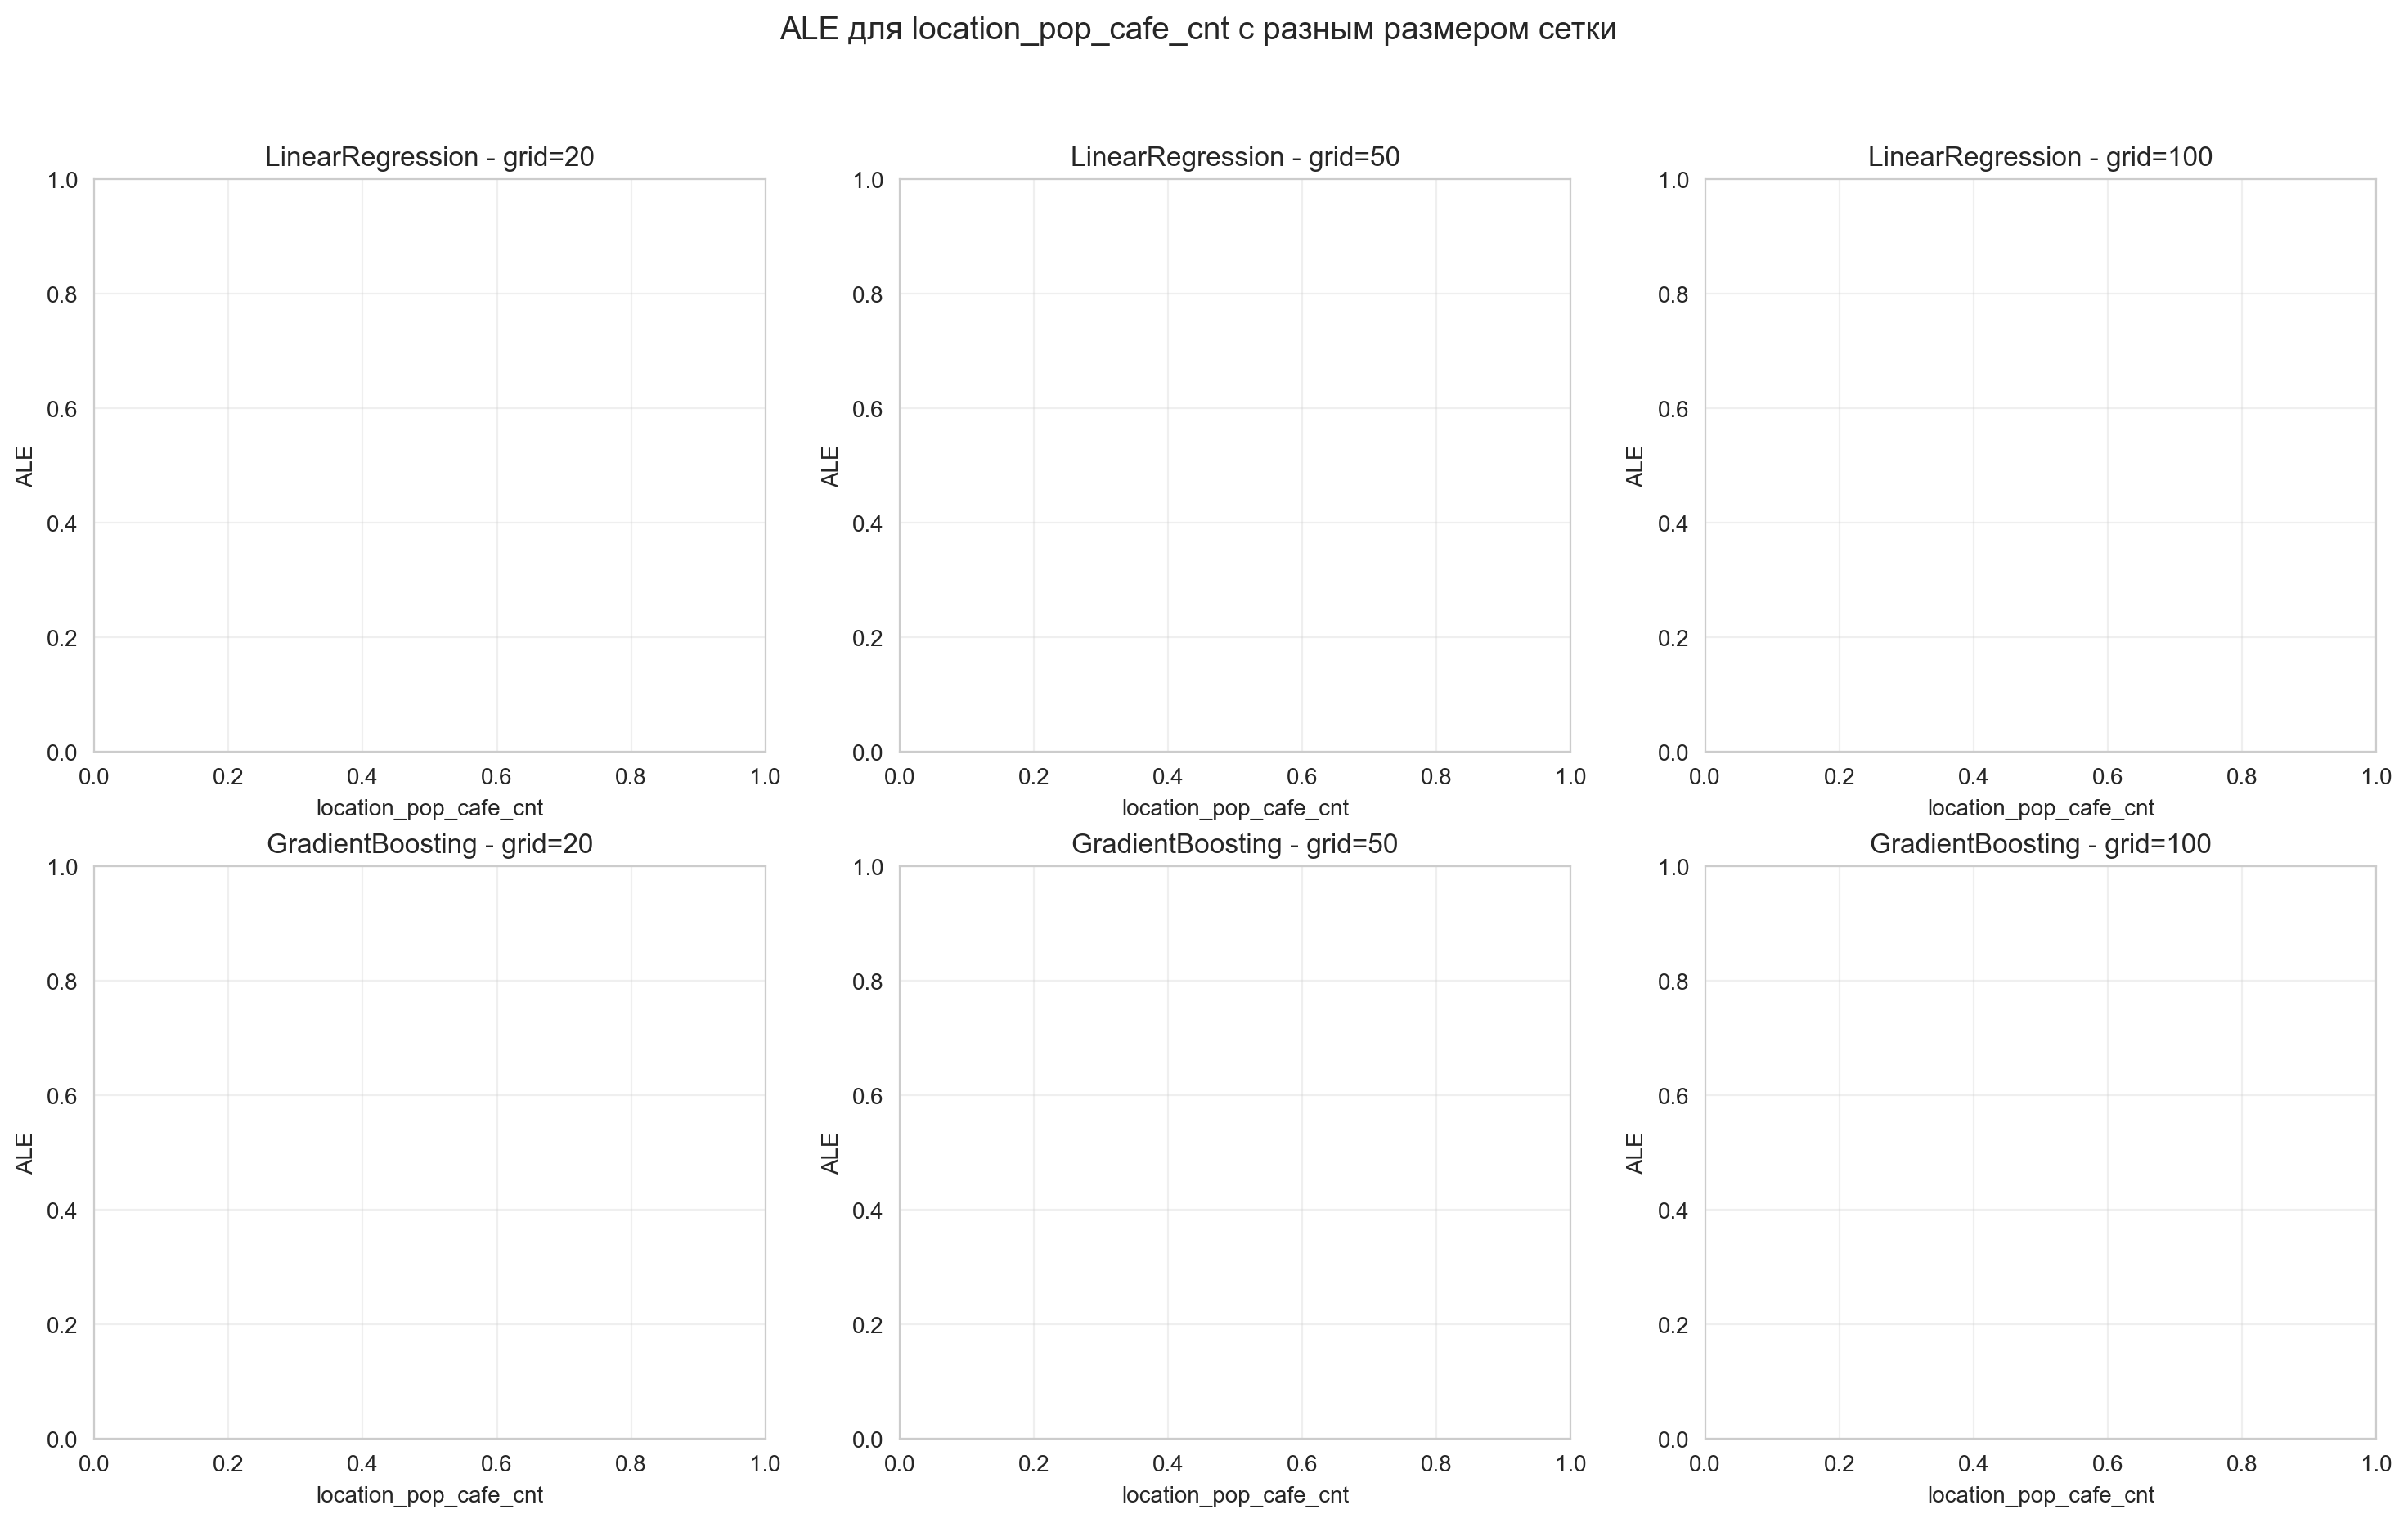

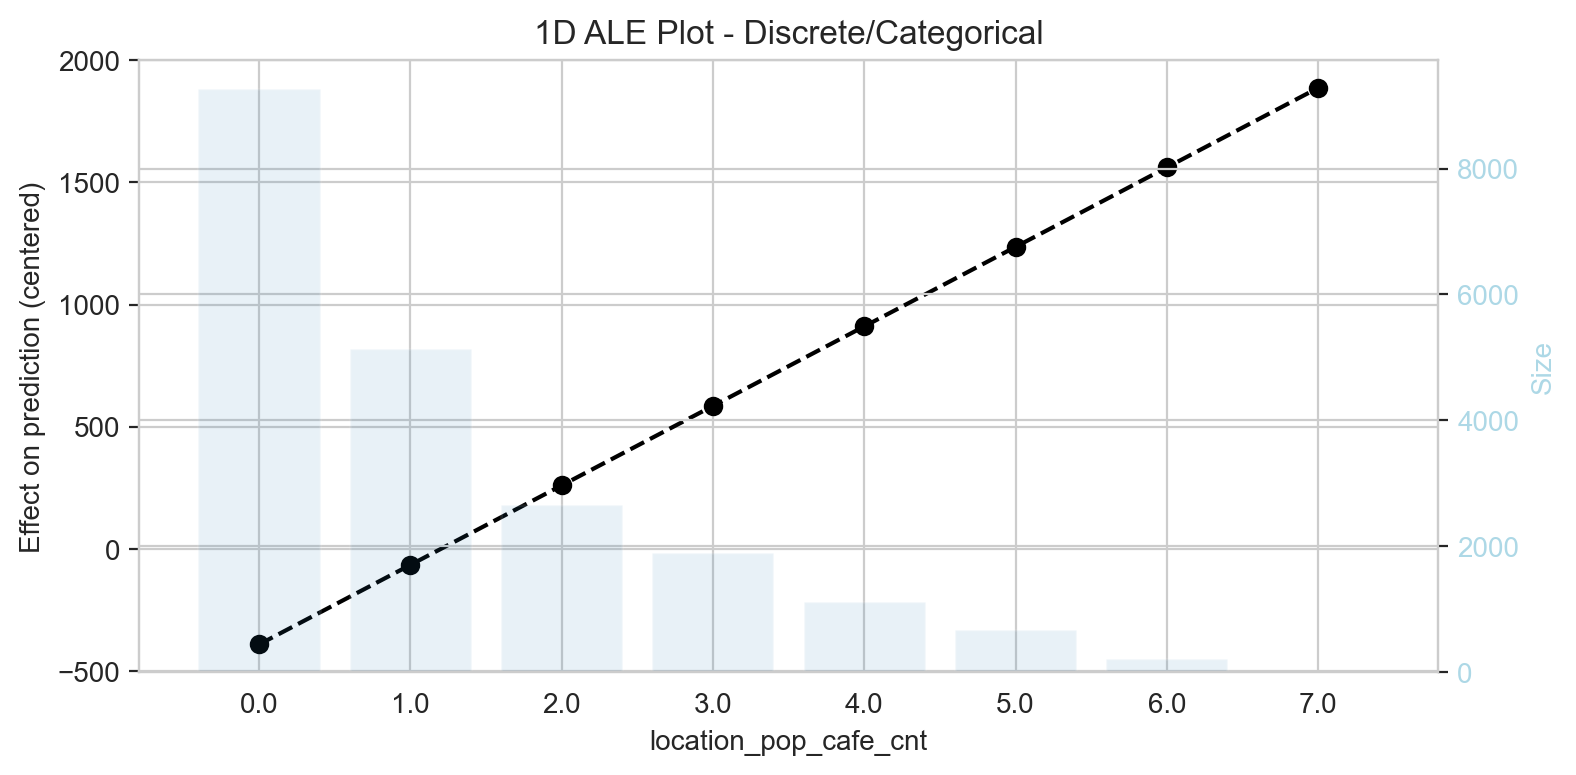

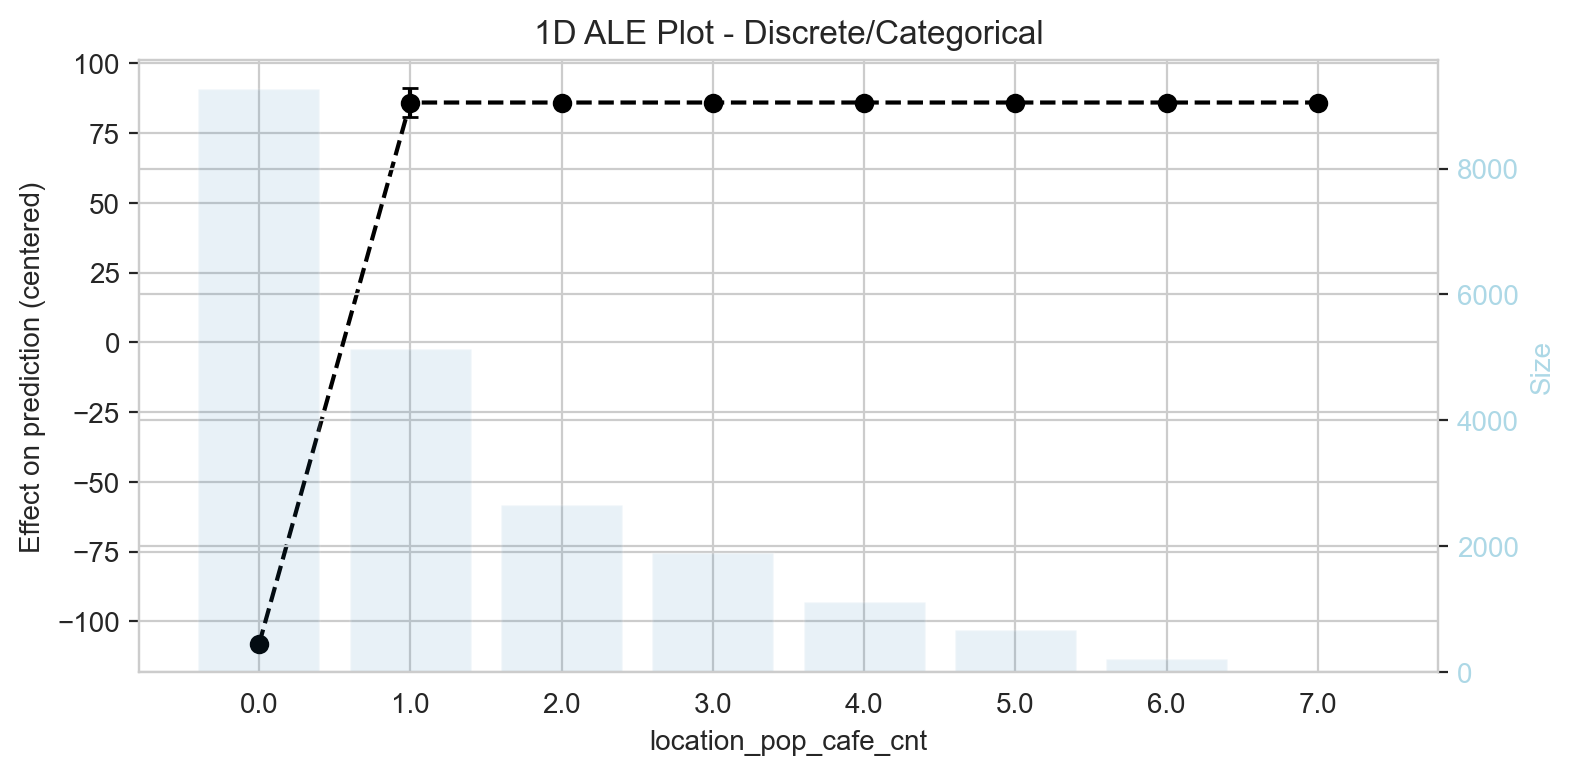

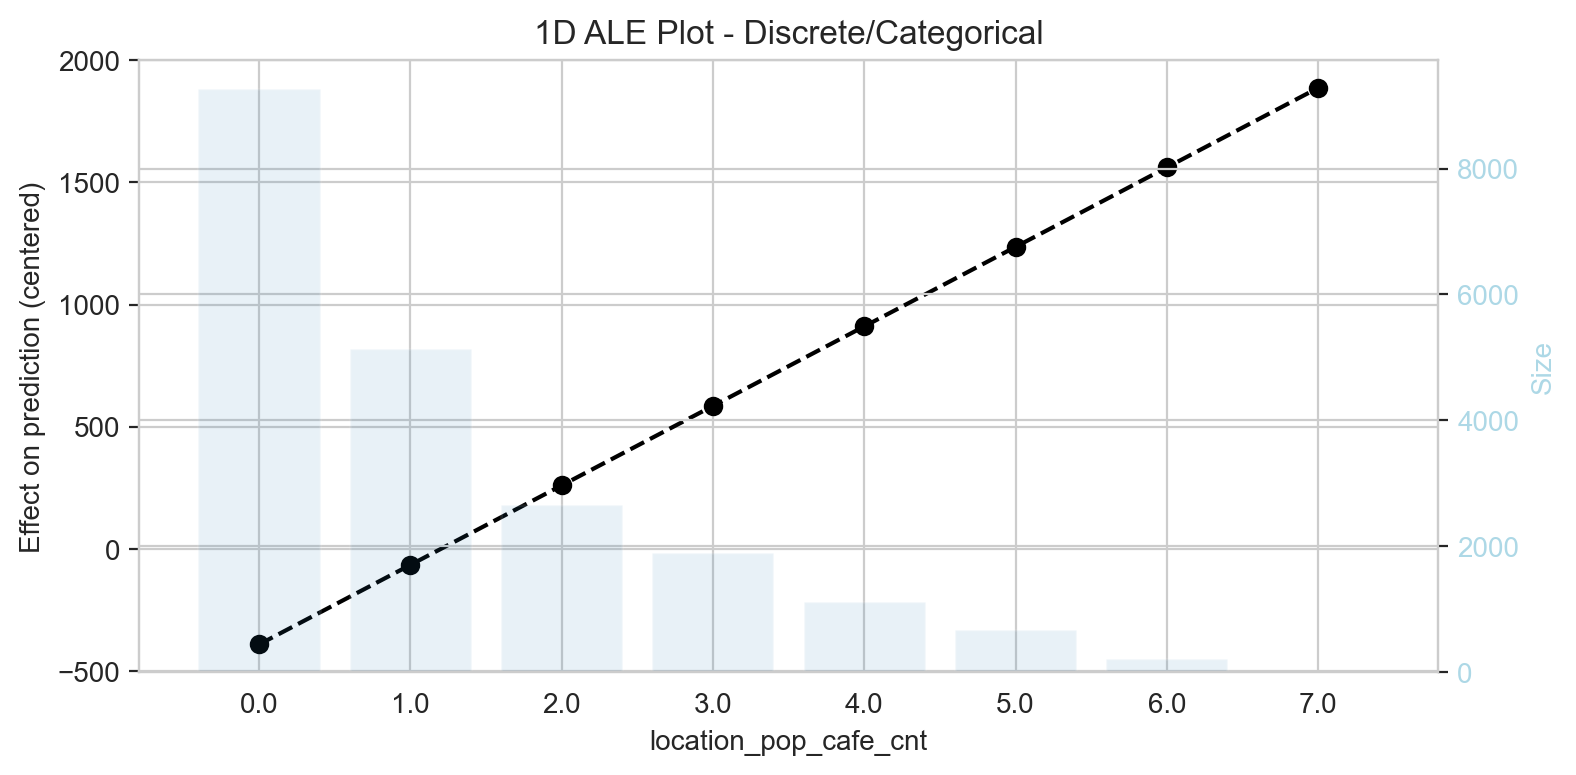

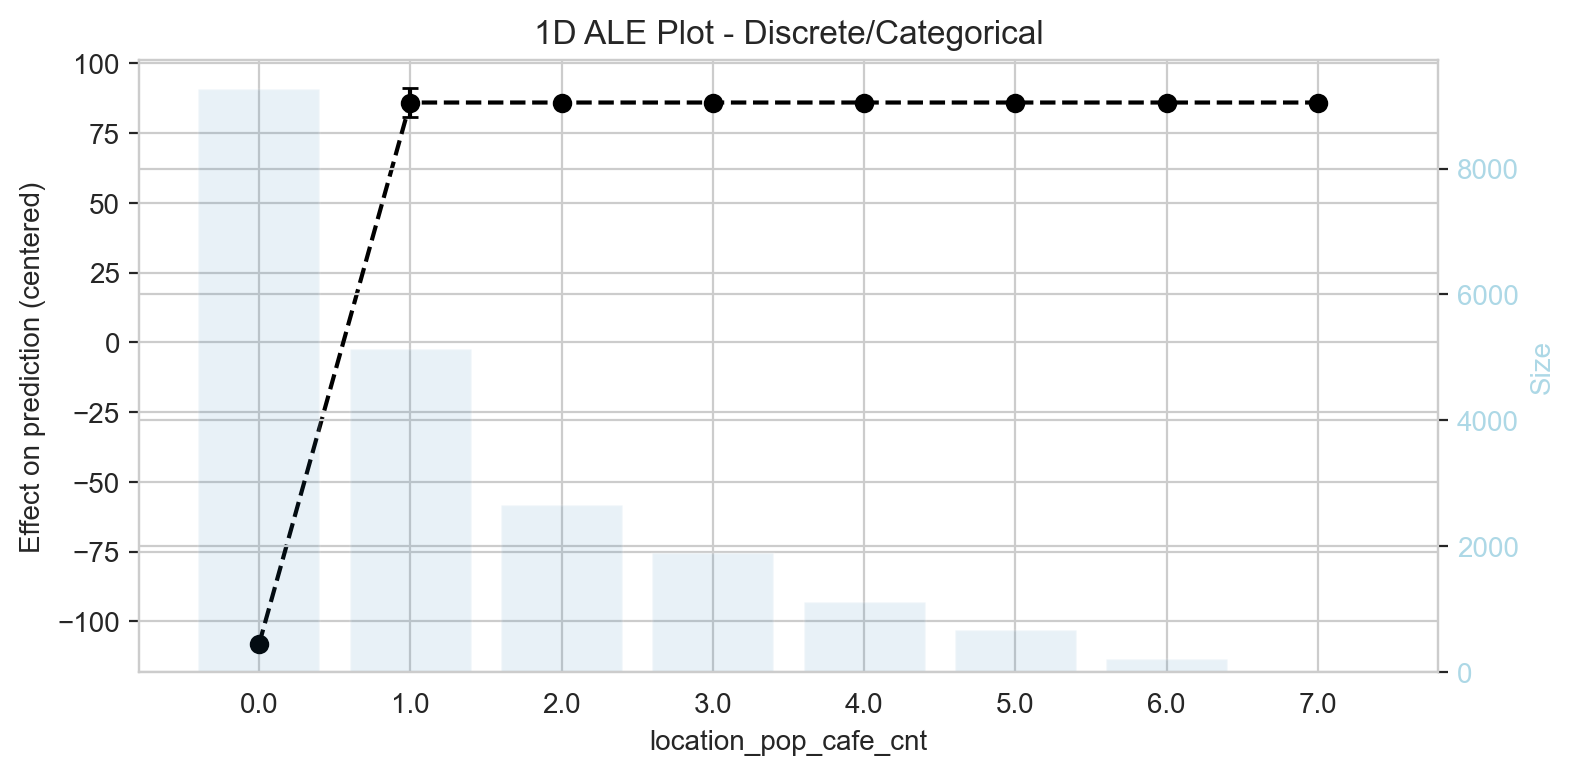

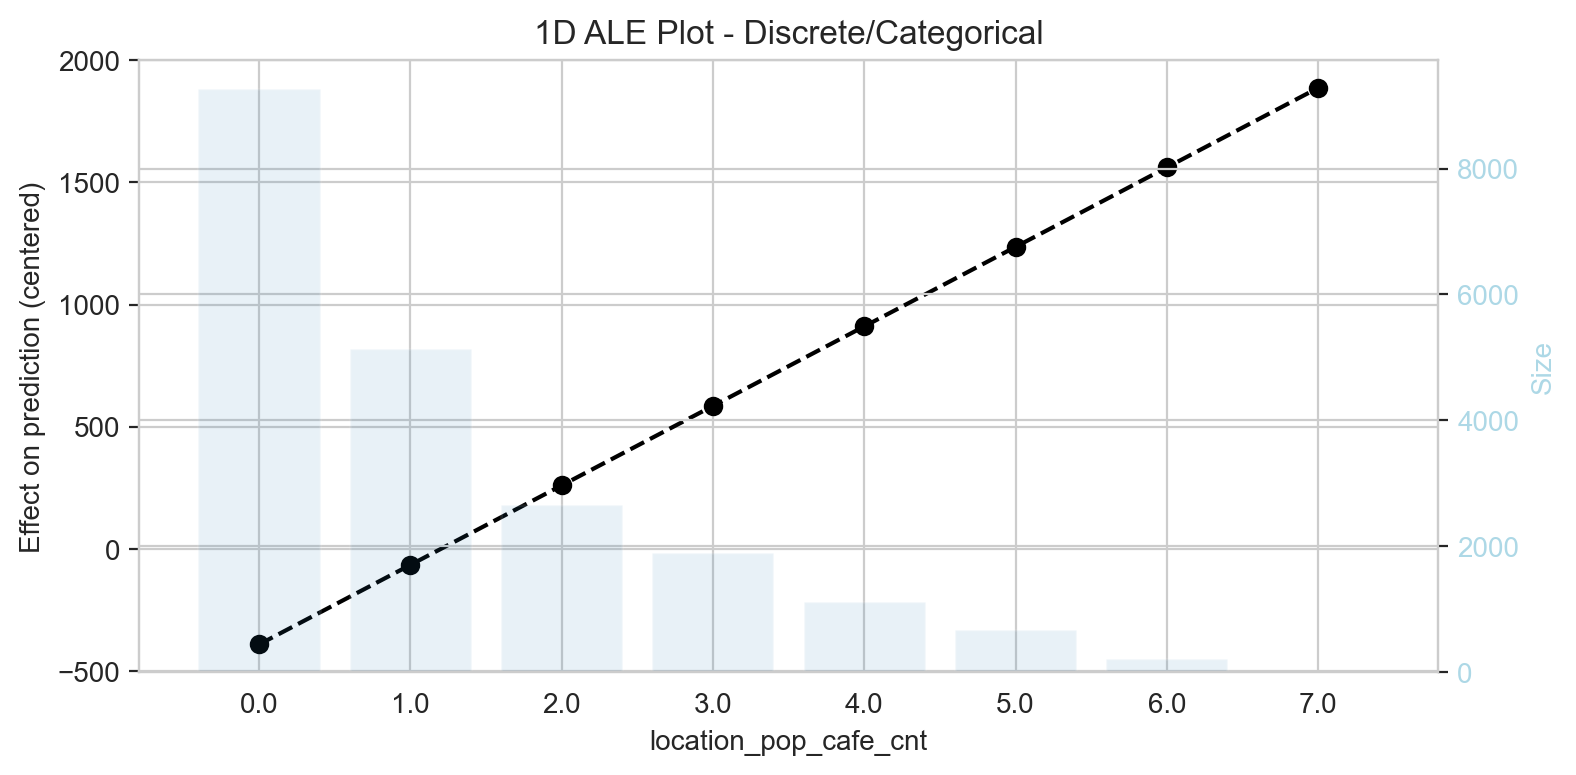

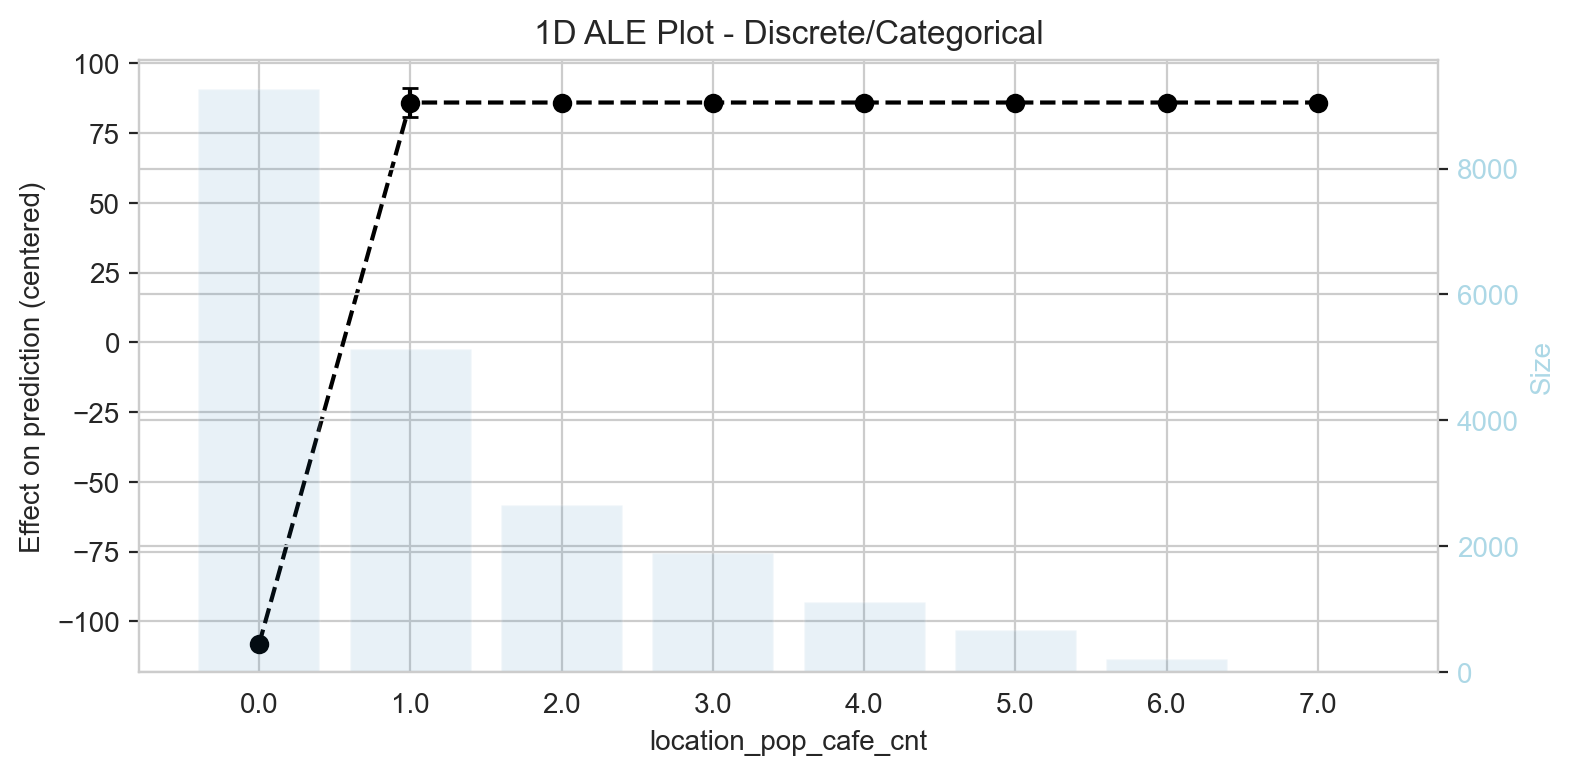

In [51]:
grid_sizes = [20, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'ALE для {feature_to_analyze} с разным размером сетки', fontsize=14)

for idx, grid_size in enumerate(grid_sizes):
    ale_lr_grid = ale(
        X=X_train_original,
        model=lr,
        feature=[feature_to_analyze],
        grid_size=grid_size
    )
    axes[0, idx].set_title(f'LinearRegression - grid={grid_size}')
    axes[0, idx].set_xlabel(feature_to_analyze)
    axes[0, idx].set_ylabel('ALE')
    axes[0, idx].grid(True, alpha=0.3)

    ale_gb_grid = ale(
        X=X_train_original,
        model=gb,
        feature=[feature_to_analyze],
        grid_size=grid_size
    )
    axes[1, idx].set_title(f'GradientBoosting - grid={grid_size}')
    axes[1, idx].set_xlabel(feature_to_analyze)
    axes[1, idx].set_ylabel('ALE')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

n_repeats_list = [5, 10, 20, 50]

fig, axes = plt.subplots(2, len(n_repeats_list), figsize=(20, 10))
fig.suptitle('Permutation Importance для разных моделей и количества перестановок', fontsize=14)

for idx, n_repeats in enumerate(n_repeats_list):
    perm_importance_lr = permutation_importance(
        lr, X_test_scaled, y_test,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    sorted_idx_lr = perm_importance_lr.importances_mean.argsort()[::-1][:10]

    axes[0, idx].barh(range(10), perm_importance_lr.importances_mean[sorted_idx_lr][::-1],
                      xerr=perm_importance_lr.importances_std[sorted_idx_lr][::-1],
                      capsize=3, color='blue', alpha=0.7)
    axes[0, idx].set_yticks(range(10))
    axes[0, idx].set_yticklabels([feature_names[i] for i in sorted_idx_lr][::-1], fontsize=8)
    axes[0, idx].set_xlabel('Importance')
    axes[0, idx].set_title(f'LinearRegression - n_repeats={n_repeats}')
    axes[0, idx].grid(True, alpha=0.3)

    perm_importance_gb = permutation_importance(
        gb, X_test_scaled, y_test,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    sorted_idx_gb = perm_importance_gb.importances_mean.argsort()[::-1][:10]

    axes[1, idx].barh(range(10), perm_importance_gb.importances_mean[sorted_idx_gb][::-1],
                      xerr=perm_importance_gb.importances_std[sorted_idx_gb][::-1],
                      capsize=3, color='green', alpha=0.7)
    axes[1, idx].set_yticks(range(10))
    axes[1, idx].set_yticklabels([feature_names[i] for i in sorted_idx_gb][::-1], fontsize=8)
    axes[1, idx].set_xlabel('Importance')
    axes[1, idx].set_title(f'GradientBoosting - n_repeats={n_repeats}')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("STATISTICS FOR LINEARREGRESSION")
print("=" * 60)

for n_repeats in n_repeats_list:
    perm_importance_lr = permutation_importance(
        lr, X_test_scaled, y_test,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    sorted_idx = perm_importance_lr.importances_mean.argsort()[::-1][:5]

    print(f"\nn_repeats = {n_repeats}:")
    for i in sorted_idx:
        print(
            f"  {feature_names[i]}: mean={perm_importance_lr.importances_mean[i]:.4f}, std={perm_importance_lr.importances_std[i]:.4f}")

print("\n" + "=" * 60)
print("STATISTICS FOR GRADIENTBOOSTING")
print("=" * 60)

for n_repeats in n_repeats_list:
    perm_importance_gb = permutation_importance(
        gb, X_test_scaled, y_test,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    sorted_idx = perm_importance_gb.importances_mean.argsort()[::-1][:5]

    print(f"\nn_repeats = {n_repeats}:")
    for i in sorted_idx:
        print(
            f"  {feature_names[i]}: mean={perm_importance_gb.importances_mean[i]:.4f}, std={perm_importance_gb.importances_std[i]:.4f}")

In [ ]:
n_repeats_stability = 100

perm_importance_lr_stable = permutation_importance(
    lr, X_test_scaled, y_test,
    n_repeats=n_repeats_stability,
    random_state=42,
    n_jobs=-1
)

perm_importance_gb_stable = permutation_importance(
    gb, X_test_scaled, y_test,
    n_repeats=n_repeats_stability,
    random_state=42,
    n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sorted_idx_lr = perm_importance_lr_stable.importances_mean.argsort()[::-1][:15]
axes[0].barh(range(15), perm_importance_lr_stable.importances_mean[sorted_idx_lr][::-1],
             xerr=perm_importance_lr_stable.importances_std[sorted_idx_lr][::-1],
             capsize=3, color='blue', alpha=0.7)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([feature_names[i] for i in sorted_idx_lr][::-1], fontsize=9)
axes[0].set_xlabel('Importance')
axes[0].set_title(f'LinearRegression - n_repeats={n_repeats_stability}')
axes[0].grid(True, alpha=0.3)

sorted_idx_gb = perm_importance_gb_stable.importances_mean.argsort()[::-1][:15]
axes[1].barh(range(15), perm_importance_gb_stable.importances_mean[sorted_idx_gb][::-1],
             xerr=perm_importance_gb_stable.importances_std[sorted_idx_gb][::-1],
             capsize=3, color='green', alpha=0.7)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([feature_names[i] for i in sorted_idx_gb][::-1], fontsize=9)
axes[1].set_xlabel('Importance')
axes[1].set_title(f'GradientBoosting - n_repeats={n_repeats_stability}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("STABILITY ANALYSIS")
print("=" * 60)

lr_mean = perm_importance_lr_stable.importances_mean
lr_std = perm_importance_lr_stable.importances_std
lr_cv = lr_std / np.abs(lr_mean) * 100

gb_mean = perm_importance_gb_stable.importances_mean
gb_std = perm_importance_gb_stable.importances_std
gb_cv = gb_std / np.abs(gb_mean) * 100

print("\nLinearRegression - Coefficient of Variation (%):")
top5_idx_lr = lr_mean.argsort()[::-1][:5]
for i in top5_idx_lr:
    print(f"  {feature_names[i]}: CV={lr_cv[i]:.2f}%")

print("\nGradientBoosting - Coefficient of Variation (%):")
top5_idx_gb = gb_mean.argsort()[::-1][:5]
for i in top5_idx_gb:
    print(f"  {feature_names[i]}: CV={gb_cv[i]:.2f}%")

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

X_test_num = X_test_scaled[:, :len(num_cols)]
X_test_cat = X_test_scaled[:, len(num_cols):] if cat_feature_names else None

base_values = {}
for col in num_cols:
    base_values[col] = X_train[col].median()


def shift_feature(X, feature_idx, beta, base_value):
    X_shifted = X.copy()
    current_values = X_shifted[:, feature_idx]
    X_shifted[:, feature_idx] = (1 - beta) * current_values + beta * base_value
    return X_shifted


betas = [0, 0.1, 0.25, 0.5, 0.75, 1.0]

importance_results = {}

for beta in betas:
    print(f"\nProcessing beta = {beta}")
    mape_scores = {}

    for idx, col in enumerate(num_cols):
        base_val_scaled = scale_single_feature(idx, base_values[col])

        X_test_shifted_num = shift_feature(X_test_num, idx, beta, base_val_scaled)

        if X_test_cat is not None:
            X_test_shifted = np.hstack([X_test_shifted_num, X_test_cat])
        else:
            X_test_shifted = X_test_shifted_num

        y_pred_original = gb.predict(X_test_scaled)
        y_pred_shifted = gb.predict(X_test_shifted)

        mape_original = mean_absolute_percentage_error(y_test, y_pred_original)
        mape_shifted = mean_absolute_percentage_error(y_test, y_pred_shifted)

        mape_scores[col] = mape_shifted - mape_original

    importance_results[beta] = mape_scores

importance_df = pd.DataFrame(importance_results).T
print("\nImportance (MAPE difference) for each beta:")
print(importance_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_features = importance_df.mean().sort_values(ascending=False).head(10).index.tolist()

for feature in top_features:
    axes[0].plot(betas, importance_df[feature], marker='o', label=feature, linewidth=2)

axes[0].set_xlabel('Beta')
axes[0].set_ylabel('MAPE difference')
axes[0].set_title('Feature importance by shifting to median')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

importance_at_beta1 = importance_df.loc[1.0].sort_values(ascending=False).head(10)
axes[1].barh(range(len(importance_at_beta1)), importance_at_beta1.values)
axes[1].set_yticks(range(len(importance_at_beta1)))
axes[1].set_yticklabels(importance_at_beta1.index)
axes[1].set_xlabel('MAPE difference')
axes[1].set_title('Feature importance at beta=1.0')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    gb, X_test_scaled, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_importance_dict = {}
for idx, col in enumerate(num_cols):
    perm_importance_dict[col] = perm_importance.importances_mean[idx]

perm_importance_df = pd.DataFrame({
    'permutation_importance': perm_importance_dict,
    'shift_to_median_beta1': importance_df.loc[1.0]
}).sort_values('permutation_importance', ascending=False)

print("\nComparison of feature importance methods:")
print(perm_importance_df.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_features_perm = perm_importance_df.head(10).index.tolist()
top_features_shift = perm_importance_df.sort_values('shift_to_median_beta1', ascending=False).head(10).index.tolist()

axes[0].barh(range(len(top_features_perm)), perm_importance_df.loc[top_features_perm, 'permutation_importance'].values)
axes[0].set_yticks(range(len(top_features_perm)))
axes[0].set_yticklabels(top_features_perm)
axes[0].set_xlabel('Importance')
axes[0].set_title('Permutation Importance')
axes[0].grid(True, alpha=0.3)

axes[1].barh(range(len(top_features_shift)), perm_importance_df.loc[top_features_shift, 'shift_to_median_beta1'].values)
axes[1].set_yticks(range(len(top_features_shift)))
axes[1].set_yticklabels(top_features_shift)
axes[1].set_xlabel('MAPE difference')
axes[1].set_title('Shift to Median Importance (beta=1.0)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

common_features = set(perm_importance_df.head(15).index) & set(
    perm_importance_df.sort_values('shift_to_median_beta1', ascending=False).head(15).index)

for feature in common_features:
    ax.scatter(perm_importance_df.loc[feature, 'permutation_importance'],
               perm_importance_df.loc[feature, 'shift_to_median_beta1'],
               s=100, alpha=0.7)
    ax.annotate(feature,
                (perm_importance_df.loc[feature, 'permutation_importance'],
                 perm_importance_df.loc[feature, 'shift_to_median_beta1']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Permutation Importance')
ax.set_ylabel('Shift to Median Importance (beta=1.0)')
ax.set_title('Correlation between feature importance methods')
ax.grid(True, alpha=0.3)

correlation = perm_importance_df['permutation_importance'].corr(perm_importance_df['shift_to_median_beta1'])
print(f"\nCorrelation between methods: {correlation:.4f}")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sensitivity analysis for different beta values', fontsize=14)

top_5_features = perm_importance_df.head(5).index.tolist()

for idx, feature in enumerate(top_5_features):
    ax = axes[idx // 2, idx % 2]
    ax.plot(betas, importance_df[feature], marker='o', linewidth=2, color='blue')
    ax.fill_between(betas,
                    importance_df[feature] - perm_importance_df.loc[feature, 'permutation_importance'] * 0.2,
                    importance_df[feature] + perm_importance_df.loc[feature, 'permutation_importance'] * 0.2,
                    alpha=0.2, color='gray')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Beta')
    ax.set_ylabel('MAPE difference')
    ax.set_title(f'Feature: {feature}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

importance_changes = importance_df.diff().abs().mean()
print("\nAverage change in importance between beta steps:")
print(importance_changes.sort_values(ascending=False).head(10).round(4))

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 
